[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/linear_algebra/05_determinants_trace_and_matrix_polynomials/first_principles.ipynb)

# Module 05 — Determinants, Trace, and Matrix Polynomials

## 1. Why This Module Exists

A square matrix carries $n^2$ numbers. Almost every question one asks about it — is it
invertible, how much does it scale volume, what does it do to a probability density, how do its
powers behave — is answered by a handful of scalars built out of those $n^2$ entries.

Two of those scalars do most of the work. The **determinant** is the signed volume factor of the
map $x \mapsto Ax$, and it vanishes exactly when the map is not invertible. The **trace** is the
infinitesimal version of the same thing: the rate at which volume changes when the map is turned
on slowly.

The bridge between them is the **characteristic polynomial** $p_A(t) = \det(tI - A)$, whose
coefficients interpolate between trace and determinant. Its roots are the eigenvalues, which
[Module 06](../06_eigenvalues_eigenvectors_spectral_theory/) then studies with eigenvectors
attached; here they appear only as roots, because that is all the determinant needs them to be.

The module's own theorem is the **Cayley-Hamilton theorem**: a matrix is a root of its own
characteristic polynomial. It collapses the infinite list $I, A, A^2, A^3, \dots$ into the
finite list $I, A, \dots, A^{n-1}$, which is why $A^{-1}$, $e^{A}$ and every other matrix
function can be written as a polynomial of degree less than $n$.

## 2. Intuition

Take the unit square in $\mathbb{R}^2$, with corners $0$, $e_1$, $e_1 + e_2$, $e_2$. Apply $A$.
The square becomes the parallelogram spanned by the two columns of $A$.

The determinant is the **signed** area of that parallelogram. Its magnitude says how much area
was stretched; its sign says whether the pair $(Ae_1, Ae_2)$ still turns counter-clockwise the
way $(e_1, e_2)$ did.

Three axioms pin this down and nothing else is needed. Volume is additive when you slide one
edge along a direction, which makes it linear in each column. A parallelogram with two equal
edges is flat, so the determinant vanishes on repeated columns. And the unit cube has volume
one.

The trace is the same picture in miniature. Replace $A$ by $I + hA$ for small $h$: the unit cube
grows by a factor $1 + h\operatorname{tr}(A) + O(h^2)$, so the trace is the *rate* of volume
change, not the amount. That single sentence is the reason the trace appears in the divergence
of a flow, in the log-density of a normalizing flow, and in Jacobi's formula below.

Matrix polynomials enter because the determinant of $tI - A$ is a polynomial whose roots control
the powers of $A$ — and Cayley-Hamilton says $A$ itself is one of those roots.

The first code cell is the notebook preamble. It fixes plotting defaults, seeds the single
random generator used everywhere below, and prints the machine epsilon that later residual
claims are measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps
print(f"machine epsilon = {EPS:.4e}")

machine epsilon = 2.2204e-16


Every residual reported later in this notebook is quoted as a multiple of this number.

The next cell draws the picture described above. The left panel maps the unit square through

$$
A = \begin{pmatrix} 2 & 1 \\ 1 & 3 \end{pmatrix}, \qquad \det A = 2 \cdot 3 - 1 \cdot 1 = 5,
$$

and shades both regions so the area ratio can be read off. The right panel repeats the
experiment for a matrix with negative determinant and for a singular matrix, to show what the
sign and the zero mean geometrically.

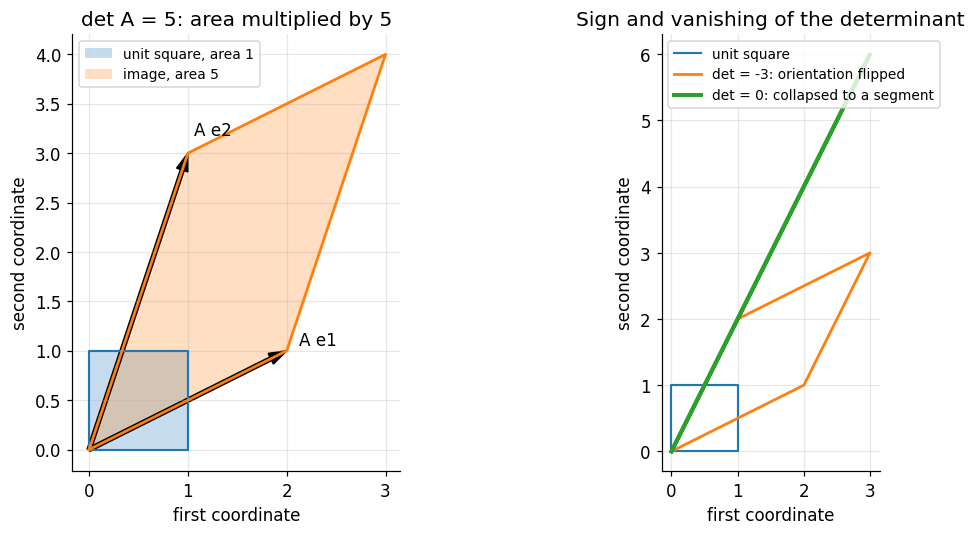

A_pos: det = +5.000000   rank = 2
A_neg: det = -3.000000   rank = 2
A_sing: det = +0.000000   rank = 1


In [2]:
square = np.array([[0.0, 1.0, 1.0, 0.0, 0.0],
                   [0.0, 0.0, 1.0, 1.0, 0.0]])

A_pos = np.array([[2.0, 1.0], [1.0, 3.0]])
A_neg = np.array([[1.0, 2.0], [2.0, 1.0]])
A_sing = np.array([[1.0, 2.0], [2.0, 4.0]])

fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.0))

ax = axes[0]
img = A_pos @ square
ax.fill(square[0], square[1], alpha=0.25, label="unit square, area 1")
ax.fill(img[0], img[1], alpha=0.25, label=f"image, area {abs(np.linalg.det(A_pos)):.0f}")
ax.plot(square[0], square[1], lw=1.4)
ax.plot(img[0], img[1], lw=1.8)
for v, name in [(A_pos[:, 0], "A e1"), (A_pos[:, 1], "A e2")]:
    ax.arrow(0, 0, v[0], v[1], width=0.04, length_includes_head=True, color="k")
    ax.annotate(name, v * 1.06)
ax.set_aspect("equal")
ax.set_xlabel("first coordinate")
ax.set_ylabel("second coordinate")
ax.set_title("det A = 5: area multiplied by 5")
ax.legend(loc="upper left", fontsize=9)

ax = axes[1]
neg = A_neg @ square
sing = A_sing @ square
ax.plot(square[0], square[1], lw=1.4, label="unit square")
ax.plot(neg[0], neg[1], lw=1.8, label=f"det = {np.linalg.det(A_neg):.0f}: orientation flipped")
ax.plot(sing[0], sing[1], lw=2.6, label=f"det = {abs(np.linalg.det(A_sing)):.0f}: collapsed to a segment")
ax.set_aspect("equal")
ax.set_xlabel("first coordinate")
ax.set_ylabel("second coordinate")
ax.set_title("Sign and vanishing of the determinant")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

for M, name in [(A_pos, "A_pos"), (A_neg, "A_neg"), (A_sing, "A_sing")]:
    print(f"{name}: det = {np.linalg.det(M):+.6f}   rank = {np.linalg.matrix_rank(M)}")

The shaded image in the left panel has exactly five times the area of the unit square, which is
$\det A$.

In the right panel the second matrix has determinant $-3$: the image is a genuine parallelogram
of area $3$, but traversing its corners in the order inherited from the square now turns the
other way. The third matrix has determinant $0$ and rank $1$, and its image is a segment: the
two columns are parallel, so the parallelogram is flat.

## 3. Definitions

Throughout, $\mathbb{F}$ is $\mathbb{R}$ or $\mathbb{C}$ unless stated otherwise, matrices are
$n \times n$ unless the shape is given, and vectors are columns. Symbols follow
[the notation register](../../docs/notation.md): transpose is $A^{\top}$, conjugate transpose is
$A^{\ast}$, norms are written $\lVert x \rVert$, and eigenvalues are listed in descending order
when they are real.

### Definition 3.1 — Trace

For $A \in \mathbb{F}^{n \times n}$,

$$
\operatorname{tr}(A) = \sum_{i=1}^{n} A_{ii} .
$$

Only the diagonal is read, so the trace costs $n$ additions no matter how dense $A$ is.

### Definition 3.2 — Determinant, axiomatically

Write $A = [\, a_1 \;\; a_2 \;\; \cdots \;\; a_n \,]$ for the columns of $A$. A function
$D : (\mathbb{F}^n)^n \to \mathbb{F}$ is

- **multilinear** if it is linear in each argument with the others held fixed;
- **alternating** if $D(a_1, \dots, a_n) = 0$ whenever $a_i = a_j$ for some $i \neq j$;
- **normalized** if $D(e_1, \dots, e_n) = 1$.

The **determinant** $\det$ is the unique multilinear alternating normalized function
(Theorem 4.1).

**Why "alternating" is defined by vanishing, not by sign flip.** Vanishing on repeated columns
implies that swapping two columns flips the sign, by expanding
$D(\dots, u+v, \dots, u+v, \dots) = 0$.

The converse fails in characteristic $2$, and vacuously so: there $-x = x$ for every $x$, so the
sign-flip condition holds for *every* function and can imply nothing at all. The vanishing form
is the one that makes Theorem 4.1 true over every commutative ring.

### Definition 3.3 — Permutations and their sign

$S_n$ is the group of bijections $\sigma : \{1, \dots, n\} \to \{1, \dots, n\}$. Every $\sigma$
is a product of transpositions, and the parity of the number of transpositions is well defined;

$$
\operatorname{sgn}(\sigma) = (-1)^{\#\text{transpositions}} \in \{+1, -1\} .
$$

Two facts are used below: $\operatorname{sgn}$ is multiplicative, and
$\operatorname{sgn}(\sigma^{-1}) = \operatorname{sgn}(\sigma)$.

### Definition 3.4 — Minor, cofactor, adjugate

Let $M_{ij} \in \mathbb{F}^{(n-1) \times (n-1)}$ be $A$ with row $i$ and column $j$ deleted. The
**$(i,j)$ cofactor** is

$$
C_{ij} = (-1)^{i+j} \det(M_{ij}),
$$

and the **adjugate** is the transposed cofactor matrix,

$$
(\operatorname{adj} A)_{ij} = C_{ji} .
$$

A **principal $k \times k$ minor** is $\det(A_{S,S})$ for an index set $S$ of size $k$, that is,
a minor whose deleted rows and columns carry the same indices.

### Definition 3.5 — Characteristic polynomial, eigenvalue, spectrum

The **characteristic polynomial** of $A \in \mathbb{F}^{n \times n}$ is

$$
p_A(t) = \det(tI - A),
$$

a monic polynomial of degree $n$. An **eigenvalue** is a root of $p_A$, equivalently a scalar
$\lambda$ for which $A - \lambda I$ is singular, and the **spectrum**
$\operatorname{spec}(A)$ is the multiset of roots in $\mathbb{C}$, listed with multiplicity.

> [!NOTE]
> **Sign convention.** [Module 06](../06_eigenvalues_eigenvectors_spectral_theory/) writes the
> characteristic polynomial as $\det(A - zI)$, which equals $(-1)^n p_A(z)$. The two have the
> same roots with the same multiplicities. This module uses the monic form $\det(tI - A)$,
> because Cayley-Hamilton and the companion matrix both read off its coefficients directly.

### Definition 3.6 — Matrix polynomial, annihilating polynomial, minimal polynomial

For $q(t) = \sum_{k=0}^{d} q_k t^k \in \mathbb{F}[t]$ put
$q(A) = \sum_{k=0}^{d} q_k A^{k}$, with $A^0 = I$.

$q$ **annihilates** $A$ when $q(A) = 0$. The **minimal polynomial** $m_A$ is the monic
annihilating polynomial of least degree (Theorem 4.8 shows there is exactly one).

### Definition 3.7 — Four matrix products

For $u \in \mathbb{F}^{m}$, $v \in \mathbb{F}^{n}$, and matrices of the shapes indicated:

- **outer product** $u v^{\top} \in \mathbb{F}^{m \times n}$, entries $u_i v_j$; always rank at
  most one;
- **Hadamard product** $(A \circ B)_{ij} = A_{ij} B_{ij}$, requiring $A$ and $B$ to have the same
  shape;
- **Kronecker product**, for $A \in \mathbb{F}^{m \times n}$ and $B \in \mathbb{F}^{p \times q}$,

$$
A \otimes B = \begin{pmatrix}
A_{11} B & \cdots & A_{1n} B \\
\vdots & \ddots & \vdots \\
A_{m1} B & \cdots & A_{mn} B
\end{pmatrix} \in \mathbb{F}^{mp \times nq};
$$

- **Khatri-Rao product**, the column-wise Kronecker product of $A \in \mathbb{F}^{m \times k}$
  and $B \in \mathbb{F}^{p \times k}$, which must share their number of columns,

$$
A \ast B = [\, a_1 \otimes b_1 \;\; \cdots \;\; a_k \otimes b_k \,] \in \mathbb{F}^{mp \times k} .
$$

### Definition 3.8 — The vec operator

$\operatorname{vec}(X) \in \mathbb{F}^{mn}$ stacks the columns of $X \in \mathbb{F}^{m \times n}$
one under the other:

$$
\operatorname{vec}(X) = \begin{pmatrix} x_1 \\ \vdots \\ x_n \end{pmatrix}, \qquad x_j = X e_j .
$$

It is a linear bijection between $\mathbb{F}^{m \times n}$ and $\mathbb{F}^{mn}$, which is what
lets a matrix equation be handed to an ordinary linear solver.

### Definition 3.9 — Positive semidefinite

A symmetric $A \in \mathbb{R}^{n \times n}$ is **positive semidefinite**, written
$A \succeq 0$, when $x^{\top} A x \ge 0$ for every $x$, and **positive definite**,
$A \succ 0$, when $x^{\top} A x \gt 0$ for every $x \neq 0$.

### Definition 3.10 — Frobenius inner product and norm

For $A, B \in \mathbb{F}^{m \times n}$,

$$
\langle A, B \rangle_F = \operatorname{tr}(A^{\top} B) = \sum_{i,j} A_{ij} B_{ij},
\qquad
\lVert A \rVert_F = \sqrt{\langle A, A \rangle_F} .
$$

This is the ordinary Euclidean inner product on $\mathbb{F}^{mn}$, read through
Definition 3.8: $\langle A, B\rangle_F = \operatorname{vec}(A)^{\top}\operatorname{vec}(B)$.

## 4. Main Results

Theorems 4.1 to 4.4 build the determinant from its axioms and extract the tools that use it:
the Leibniz formula, transpose invariance, multiplicativity, and the cofactor apparatus.

Theorems 4.5 and 4.6 do the same for the trace and connect both scalars to the characteristic
polynomial. Theorem 4.7 — the result this module is named after — is Cayley-Hamilton, and
Theorem 4.8 is its refinement to the minimal polynomial.

Theorem 4.9 differentiates the determinant. Lemma 4.10 supplies the one structural fact needed
by Theorem 4.11, and Theorems 4.12 and 4.13 close with the two identities the module's
applications lean on.

### Theorem 4.1 — Existence and uniqueness of the determinant, and the Leibniz formula

Let $D : (\mathbb{F}^n)^n \to \mathbb{F}$ be multilinear and alternating in the sense of
Definition 3.2. Then for every $A$,

$$
D(a_1, \dots, a_n) = D(e_1, \dots, e_n) \sum_{\sigma \in S_n} \operatorname{sgn}(\sigma) \prod_{j=1}^{n} A_{\sigma(j), j} .
$$

Consequently there is exactly one multilinear alternating normalized function, and it is

$$
\boxed{\ \det(A) = \sum_{\sigma \in S_n} \operatorname{sgn}(\sigma) \prod_{j=1}^{n} A_{\sigma(j), j}\ }
$$

**Hypotheses.** Multilinearity is what lets the columns be expanded in the standard basis;
without it the sum over $\sigma$ has no meaning. Alternating is what kills every term whose
index map is not injective, cutting $n^n$ terms down to $n!$. Normalization only fixes the
overall constant, which is why the theorem is stated for a general $D$ first: that extra
generality is exactly what makes Proof 5.3 non-circular.

**Interpretation.** The determinant is not one formula among many; it is the *only* volume
function, once volume is required to be additive along each edge, flat on degenerate boxes, and
equal to one on the unit cube.

Proved as Proof 5.1.

### Theorem 4.2 — Transpose invariance

For every $A \in \mathbb{F}^{n \times n}$,

$$
\boxed{\ \det(A^{\top}) = \det(A)\ }
$$

**Hypotheses.** None beyond squareness.

**Interpretation.** Every statement about the determinant as a function of the columns holds
verbatim for the rows. This is the fact that licenses row reduction as a way to compute a
determinant defined by column axioms, and it must be proved *before* any such argument is used.

Proved as Proof 5.2.

### Theorem 4.3 — Multiplicativity and its corollaries

For all $A, B \in \mathbb{F}^{n \times n}$,

$$
\boxed{\ \det(AB) = \det(A) \det(B)\ }
$$

Consequently:

- $A$ is invertible if and only if $\det(A) \neq 0$, and then $\det(A^{-1}) = 1/\det(A)$;
- $\det(cA) = c^{n} \det(A)$ for a scalar $c$;
- $\det(S A S^{-1}) = \det(A)$, so the determinant is a property of the linear map, not of the
  basis;
- **block triangular rule**: for square diagonal blocks $X$ and $Z$ and any $Y$,

$$
\det \begin{pmatrix} X & Y \\ 0 & Z \end{pmatrix}
= \det \begin{pmatrix} X & 0 \\ Y^{\top} & Z \end{pmatrix}
= \det(X) \det(Z);
$$

- $\det$ is **not** additive: $\det(A + B) \neq \det(A) + \det(B)$ in general, and Section 7
  runs a counterexample.

**Hypotheses.** Both factors square and of the same size. For rectangular factors the statement
is false as written and is replaced by the Cauchy-Binet formula.

Proved as Proof 5.3.

### Theorem 4.4 — Laplace expansion, the adjugate identity, and Cramer's rule

Let $C_{ij}$ and $\operatorname{adj} A$ be as in Definition 3.4.

**Laplace expansion.** For every fixed row index $i$ and every fixed column index $j$,

$$
\det(A) = \sum_{k=1}^{n} A_{ik} C_{ik} = \sum_{k=1}^{n} A_{kj} C_{kj} .
$$

**Adjugate identity.**

$$
\boxed{\ A \operatorname{adj}(A) = \operatorname{adj}(A) A = \det(A) \, I\ }
$$

**Cramer's rule.** If $\det(A) \neq 0$ and $Ax = b$, then for each $i$

$$
x_i = \frac{\det(A_i)}{\det(A)},
$$

where $A_i$ is $A$ with its $i$-th column replaced by $b$.

**Hypotheses.** The adjugate identity holds for every square $A$, singular or not — both sides
are polynomials in the entries. Cramer's rule needs $\det(A) \neq 0$, which is the only place
invertibility is used.

**Interpretation.** The adjugate identity is the source of the closed-form inverse
$A^{-1} = \operatorname{adj}(A)/\det(A)$ and, in Proof 5.7, of Cayley-Hamilton. It is a
statement about polynomials in the entries, which is why it survives where $A^{-1}$ does not.

Proved as Proof 5.4.

### Theorem 4.5 — Properties of the trace

For matrices of compatible shape:

- **linearity**: $\operatorname{tr}(cA + B) = c \operatorname{tr}(A) + \operatorname{tr}(B)$;
- **transpose**: $\operatorname{tr}(A^{\top}) = \operatorname{tr}(A)$;
- **commutation**: for $A \in \mathbb{F}^{m \times n}$ and $B \in \mathbb{F}^{n \times m}$,

$$
\boxed{\ \operatorname{tr}(AB) = \operatorname{tr}(BA)\ }
$$

- **cyclic invariance**: $\operatorname{tr}(ABC) = \operatorname{tr}(BCA) = \operatorname{tr}(CAB)$;
- **similarity invariance**: $\operatorname{tr}(SAS^{-1}) = \operatorname{tr}(A)$;
- **Frobenius inner product**: $\operatorname{tr}(A^{\top}B) = \langle A, B \rangle_F$.

**Hypotheses.** The commutation rule needs only that both products are defined; the two matrices
need not be square, and the two products need not have the same size. Cyclic invariance is
invariance under *cyclic* rotation only: $\operatorname{tr}(ABC) = \operatorname{tr}(ACB)$ is
false, and Section 7 runs the counterexample.

Proved as Proof 5.5.

### Theorem 4.6 — Coefficients of the characteristic polynomial

Let $E_k(A)$ denote the sum of all $\binom{n}{k}$ principal $k \times k$ minors of $A$, with
$E_0 = 1$. Then

$$
\boxed{\ p_A(t) = \det(tI - A) = \sum_{k=0}^{n} (-1)^{k} E_k(A) \, t^{n-k}\ }
$$

In particular $E_1(A) = \operatorname{tr}(A)$ and $E_n(A) = \det(A)$, so

$$
p_A(t) = t^{n} - \operatorname{tr}(A)\, t^{n-1} + \cdots + (-1)^{n} \det(A) .
$$

Over $\mathbb{C}$, writing $\lambda_1, \dots, \lambda_n$ for the roots of $p_A$ with
multiplicity, $E_k(A)$ is the $k$-th elementary symmetric function of those roots. Two special
cases:

$$
\operatorname{tr}(A) = \sum_{i=1}^{n} \lambda_i, \qquad \det(A) = \prod_{i=1}^{n} \lambda_i .
$$

**Hypotheses.** The minor formula holds over any field. The symmetric-function statement needs
the roots to exist, hence $\mathbb{C}$; over $\mathbb{R}$ a matrix such as
$\left[\begin{smallmatrix} 0 & -1 \\ 1 & 0 \end{smallmatrix}\right]$ has no real roots at all,
yet its trace and determinant are still $0$ and $1$.

**Interpretation.** Trace and determinant are the two ends of one list. The coefficients in
between are the higher-order volume responses, and Theorem 4.7 turns the whole list into an
identity satisfied by $A$ itself.

Proved as Proof 5.6.

### Theorem 4.7 — Cayley-Hamilton

Let $A \in \mathbb{F}^{n \times n}$ with $\mathbb{F}$ a commutative ring, in particular
$\mathbb{R}$ or $\mathbb{C}$, and let $p_A(t) = \det(tI - A)$. Then

$$
\boxed{\ p_A(A) = 0\ }
$$

**Corollary (inverse as a polynomial).** Write
$p_A(t) = t^{n} + c_{n-1} t^{n-1} + \cdots + c_1 t + c_0$, so that
$c_0 = p_A(0) = (-1)^{n} \det(A)$. If $A$ is invertible then $c_0 \neq 0$ and

$$
A^{-1} = -\frac{1}{c_0} \bigl( A^{n-1} + c_{n-1} A^{n-2} + \cdots + c_1 I \bigr) .
$$

**Hypotheses.** Commutativity of the entries is the whole content. The proof multiplies matrices
of polynomials and compares coefficients, which requires scalars to commute past matrix entries.
Over the quaternions the conclusion is false: Section 7 runs
$A = \operatorname{diag}(i, j)$ and finds
$A^2 - (i+j)A + ij\,I = \operatorname{diag}(2k, 0) \neq 0$.

**The proof that does not work.** Substituting $t = A$ into $\det(tI - A)$ to get
$\det(A - A) = \det(0) = 0$ is meaningless: $\det(tI - A)$ is a scalar-valued function of a
scalar, so the substitution produces a number, whereas $p_A(A)$ is a matrix. Section 7 shows the
two objects side by side.

**Interpretation.** $A^{n}$ is a combination of $I, A, \dots, A^{n-1}$, so the algebra
$\mathbb{F}[A]$ has dimension at most $n$, not $n^2$. Everything downstream — the inverse
formula, matrix exponentials as degree-$(n{-}1)$ polynomials, Krylov methods — is that one
sentence.

Proved as Proof 5.7.

### Theorem 4.8 — The minimal polynomial

For every $A \in \mathbb{F}^{n \times n}$ there is a unique monic polynomial $m_A$ of least
degree with $m_A(A) = 0$, and

- $m_A$ divides every annihilating polynomial of $A$; in particular $m_A \mid p_A$ and
  $\deg m_A \le n$;
- $m_A$ and $p_A$ have exactly the same roots, though possibly with different multiplicities.

**Hypotheses.** Existence needs only that $\mathbb{F}^{n \times n}$ is finite-dimensional;
divisibility needs $\mathbb{F}[t]$ to admit division with remainder, hence $\mathbb{F}$ a field.

**Interpretation.** $p_A$ is the cheap annihilator, available from a determinant. $m_A$ is the
sharp one, and the gap between them is precisely the amount of non-diagonalizability in $A$.
Example 6.6 exhibits a $4 \times 4$ matrix where $\deg m_A = 3 \lt 4 = \deg p_A$.

Proved as Proof 5.8.

### Theorem 4.9 — Jacobi's formula, and the determinant of a matrix exponential

**Jacobi's formula.** Let $A : \mathbb{R} \to \mathbb{F}^{n \times n}$ be differentiable. Then

$$
\boxed{\ \frac{d}{dt} \det A(t) = \operatorname{tr}\bigl( \operatorname{adj}(A(t)) \, A'(t) \bigr)\ }
$$

and if in addition $A(t)$ is invertible,

$$
\frac{d}{dt} \det A(t) = \det A(t) \cdot \operatorname{tr}\bigl( A(t)^{-1} A'(t) \bigr),
\qquad
\frac{d}{dt} \log \lvert \det A(t) \rvert = \operatorname{tr}\bigl( A(t)^{-1} A'(t) \bigr).
$$

**Determinant of an exponential.** For every $A \in \mathbb{C}^{n \times n}$,

$$
\boxed{\ \det\bigl(e^{A}\bigr) = e^{\operatorname{tr}(A)}\ }
$$

**Hypotheses.** The adjugate form needs nothing but differentiability, because both sides are
polynomial in the entries. The two forms involving $A^{-1}$ need $\det A(t) \neq 0$ at the point
of evaluation. The exponential identity needs no invertibility hypothesis at all, since
$e^{A}$ is invertible automatically.

**Two identities, not one.** These are separate statements that are often quoted under the
single name "Jacobi's formula". The second is *derived from* the first in Proof 5.9, not
assumed alongside it.

**Interpretation.** The trace is the logarithmic derivative of the determinant. That is why a
flow $\dot{x} = f(x)$ changes phase-space volume at rate $\operatorname{tr}(\partial f/\partial x)$,
and why a continuous normalizing flow tracks its log-density with a trace rather than a
determinant.

Proved as Proof 5.9.

### Lemma 4.10 — Triangularization over $\mathbb{C}$

Every $A \in \mathbb{C}^{n \times n}$ can be written $A = S T S^{-1}$ with $S$ invertible and
$T$ upper triangular. The diagonal of $T$ lists the roots of $p_A$ with their multiplicities.

**Hypotheses.** Algebraic closure of the field. Over $\mathbb{R}$ the statement fails for
$\left[\begin{smallmatrix} 0 & -1 \\ 1 & 0 \end{smallmatrix}\right]$, which has no real
invariant line.

**Relation to Module 06.** [Module 06](../06_eigenvalues_eigenvectors_spectral_theory/)
strengthens this to Schur's theorem, in which $S$ may be taken unitary. That refinement is not
needed here: only the similarity form is used, and it is proved below from this module's own
determinant theory.

Proved as Proof 5.10.

### Theorem 4.11 — The Kronecker product

Let $A, C$ and $B, D$ have shapes making the products below defined.

**Mixed-product property.**

$$
\boxed{\ (A \otimes B)(C \otimes D) = (AC) \otimes (BD)\ }
$$

**vec identity.** For $A \in \mathbb{F}^{m \times n}$, $X \in \mathbb{F}^{n \times p}$,
$B \in \mathbb{F}^{p \times q}$,

$$
\boxed{\ \operatorname{vec}(AXB) = (B^{\top} \otimes A) \operatorname{vec}(X)\ }
$$

**Square case.** Let $A \in \mathbb{C}^{n \times n}$ have eigenvalues
$\lambda_1, \dots, \lambda_n$ and $B \in \mathbb{C}^{m \times m}$ have eigenvalues
$\mu_1, \dots, \mu_m$, both listed with multiplicity. Then

$$
\operatorname{tr}(A \otimes B) = \operatorname{tr}(A) \operatorname{tr}(B),
$$

$$
\operatorname{spec}(A \otimes B) = \{ \lambda_i \mu_j : 1 \le i \le n, \ 1 \le j \le m \}
\quad \text{as a multiset of } nm \text{ values},
$$

$$
\boxed{\ \det(A \otimes B) = (\det A)^{m} (\det B)^{n}\ }
$$

**Hypotheses.** The mixed-product property needs only shape compatibility. The spectrum
statement needs $\mathbb{C}$, because it is proved by triangularizing both factors
(Lemma 4.10). The determinant formula is proved without any reference to eigenvalues, so it
holds over any field.

**Non-commutativity.** $A \otimes B \neq B \otimes A$ in general, but the two are permutation
similar, so they always share their spectrum, trace and determinant.

Proved as Proof 5.11.

### Theorem 4.12 — Sylvester's determinant identity

For $A \in \mathbb{F}^{m \times n}$ and $B \in \mathbb{F}^{n \times m}$,

$$
\boxed{\ \det(I_m + AB) = \det(I_n + BA)\ }
$$

**Corollaries.** With $u, v \in \mathbb{F}^{n}$ and $X$ invertible,

$$
\det(I_n + u v^{\top}) = 1 + v^{\top} u,
\qquad
\det(X + u v^{\top}) = \det(X) \, \bigl( 1 + v^{\top} X^{-1} u \bigr) .
$$

**Hypotheses.** None beyond the shapes; $A$ and $B$ need not be square and the two identity
matrices have different sizes. The second corollary needs $X$ invertible.

**Interpretation.** A rank-$n$ update to the identity in dimension $m$ costs an $n \times n$
determinant. When $n = 1$ that is a scalar, which is why rank-one updates are cheap in Kalman
filters, Gaussian-process updates and quasi-Newton methods.

Proved as Proof 5.12.

### Theorem 4.13 — Schur product theorem

Let $A, B \in \mathbb{R}^{n \times n}$ be symmetric.

$$
\boxed{\ A \succeq 0 \ \text{ and } \ B \succeq 0 \implies A \circ B \succeq 0\ }
$$

If moreover $A \succ 0$ and $B \succ 0$, then $A \circ B \succ 0$.

**Hypotheses.** Both factors must be positive semidefinite. Positive semidefiniteness of just
one is not enough: Section 7 takes $A \succeq 0$ with $A \circ B$ indefinite for an indefinite
symmetric $B$.

**Interpretation.** The set of positive semidefinite matrices is closed under entrywise
multiplication. This is the reason products of kernels are kernels, which is what makes the
polynomial kernel $k(x,y) = (1 + x^{\top}y)^{d}$ and the ARD kernel legitimate covariance
functions.

Proved as Proof 5.13.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, existence, uniqueness and the Leibniz formula)

**Uniqueness.** Let $D$ be multilinear and alternating.

*Step 1 — expand every column in the standard basis.* Writing $a_j = \sum_{i} A_{ij} e_i$ and
using linearity in each of the $n$ slots,

$$
D(a_1, \dots, a_n) = \sum_{i_1 = 1}^{n} \cdots \sum_{i_n = 1}^{n} \left( \prod_{j=1}^{n} A_{i_j, j} \right) D(e_{i_1}, \dots, e_{i_n}) .
$$

*Step 2 — discard the non-injective index maps.* If $i_p = i_q$ for some $p \neq q$, the map $D$
receives two equal arguments and vanishes. The surviving maps $j \mapsto i_j$ are exactly the
permutations $\sigma \in S_n$.

*Step 3 — extract the sign.* Alternating implies antisymmetric: expanding

$$
0 = D(\dots, u + v, \dots, u + v, \dots)
= \underbrace{D(\dots, u, \dots, u, \dots)}_{=\,0} + D(\dots, u, \dots, v, \dots) + D(\dots, v, \dots, u, \dots) + \underbrace{D(\dots, v, \dots, v, \dots)}_{=\,0}
$$

gives $D(\dots, u, \dots, v, \dots) = -D(\dots, v, \dots, u, \dots)$. Sorting
$(e_{\sigma(1)}, \dots, e_{\sigma(n)})$ into $(e_1, \dots, e_n)$ by transpositions therefore costs
one sign per transposition, so

$$
D(e_{\sigma(1)}, \dots, e_{\sigma(n)}) = \operatorname{sgn}(\sigma) \, D(e_1, \dots, e_n) .
$$

Substituting Steps 2 and 3 into Step 1 gives the displayed formula, and normalization
$D(e_1, \dots, e_n) = 1$ pins the constant.

**Existence.** It remains to check that the Leibniz sum really is multilinear, alternating and
normalized.

*Multilinear.* Each product $\prod_j A_{\sigma(j), j}$ contains exactly one entry from each
column, so the sum is linear in each column separately.

*Normalized.* For $A = I$ the product $\prod_j \delta_{\sigma(j), j}$ is $1$ for
$\sigma = \operatorname{id}$ and $0$ otherwise, so the sum is $1$.

*Alternating.* Suppose columns $p \neq q$ are equal, so $A_{ip} = A_{iq}$ for every $i$. Let
$\tau$ be the transposition $(p \, q)$ and pair $\sigma$ with $\sigma \tau$. Then

$$
\prod_{j} A_{\sigma\tau(j), j} = A_{\sigma(q), p} A_{\sigma(p), q} \prod_{j \neq p, q} A_{\sigma(j), j}
= A_{\sigma(q), q} A_{\sigma(p), p} \prod_{j \neq p, q} A_{\sigma(j), j}
= \prod_{j} A_{\sigma(j), j},
$$

while $\operatorname{sgn}(\sigma\tau) = -\operatorname{sgn}(\sigma)$. The pairing
$\sigma \leftrightarrow \sigma\tau$ has no fixed point, so the $n!$ terms cancel in pairs and the
sum is $0$. $\blacksquare$

**Interpretation.** The uniqueness half is the workhorse: any multilinear alternating gadget one
can build is automatically a constant multiple of $\det$, and the constant is its value on the
identity. Proofs 5.3, 5.4 and 5.11 all consist of building such a gadget.

### Proof 5.2 (of Theorem 4.2, transpose invariance)

Apply the Leibniz formula of Theorem 4.1 to $A^{\top}$, whose entries are
$(A^{\top})_{ij} = A_{ji}$:

$$
\det(A^{\top}) = \sum_{\sigma \in S_n} \operatorname{sgn}(\sigma) \prod_{j=1}^{n} A_{j, \sigma(j)} .
$$

Re-index the product by $k = \sigma(j)$, so $j = \sigma^{-1}(k)$; as $j$ runs over $1, \dots, n$
so does $k$, and

$$
\prod_{j=1}^{n} A_{j, \sigma(j)} = \prod_{k=1}^{n} A_{\sigma^{-1}(k), k} .
$$

Now use $\operatorname{sgn}(\sigma) = \operatorname{sgn}(\sigma^{-1})$ and substitute
$\tau = \sigma^{-1}$; inversion is a bijection of $S_n$ onto itself, so

$$
\det(A^{\top}) = \sum_{\tau \in S_n} \operatorname{sgn}(\tau) \prod_{k=1}^{n} A_{\tau(k), k} = \det(A) . \qquad \blacksquare
$$

**Why this proof comes second and not later.** Definition 3.2 states the axioms in terms of
*columns*. Any argument that scales, swaps or combines **rows** is using row multilinearity,
which is available only through this theorem. Establishing it here is what makes Proofs 5.3 and
5.4 legitimate.

### Proof 5.3 (of Theorem 4.3, multiplicativity and corollaries)

**Multiplicativity.** Fix $A$ and regard $B$ through its columns $b_1, \dots, b_n$. The $j$-th
column of $AB$ is $A b_j$, so define

$$
D_A(b_1, \dots, b_n) = \det(A b_1, \dots, A b_n) = \det(AB) .
$$

*Multilinear:* $b_j \mapsto A b_j$ is linear, and $\det$ is linear in its $j$-th slot.

*Alternating:* if $b_p = b_q$ then $A b_p = A b_q$, and $\det$ vanishes on repeated columns.

Theorem 4.1 therefore gives $D_A(B) = D_A(I) \det(B)$, and $D_A(I) = \det(A I) = \det(A)$.
Hence $\det(AB) = \det(A) \det(B)$.

**Singularity.** If the columns of $A$ are dependent, say $a_n = \sum_{j \lt n} c_j a_j$, then
multilinearity in the last slot writes $\det(A)$ as a combination of determinants each having a
repeated column, so $\det(A) = 0$. Conversely if $A$ is invertible then
$\det(A)\det(A^{-1}) = \det(I) = 1$, so $\det(A) \neq 0$ and $\det(A^{-1}) = 1/\det(A)$.

**Scaling and similarity.** Pulling the scalar $c$ out of each of the $n$ columns gives
$\det(cA) = c^{n}\det(A)$, and
$\det(SAS^{-1}) = \det(S)\det(A)\det(S)^{-1} = \det(A)$.

**Block triangular rule.** Let $X$ be $p \times p$, $Z$ be $q \times q$, and consider

$$
F(X) = \det \begin{pmatrix} X & Y \\ 0 & Z \end{pmatrix}
$$

as a function of the $p$ columns of $X$. It is multilinear in them, and it vanishes when two of
them coincide, so Theorem 4.1 gives $F(X) = F(I_p) \det(X)$. Repeating the argument on the last
$q$ columns turns $F(I_p)$ into $\det(Z)$ times

$$
\det \begin{pmatrix} I_p & Y \\ 0 & I_q \end{pmatrix} = 1,
$$

the last value being read off the Leibniz formula, where only the identity permutation
contributes. Hence $\det \begin{pmatrix} X & Y \\ 0 & Z \end{pmatrix} = \det(X)\det(Z)$, and the
lower-triangular version follows by Theorem 4.2. $\blacksquare$

**Interpretation.** Composition of maps multiplies volume factors. Every corollary above is that
sentence specialised, including the singularity test: a map that flattens space has volume
factor zero and cannot be undone.

### Proof 5.4 (of Theorem 4.4, Laplace, adjugate and Cramer)

**Laplace expansion along column $j$.** Expand only the $j$-th column,
$a_j = \sum_{i} A_{ij} e_i$, and use linearity in that slot:

$$
\det(A) = \sum_{i=1}^{n} A_{ij} \, \det(a_1, \dots, \underbrace{e_i}_{\text{slot } j}, \dots, a_n) .
$$

It remains to identify the inner determinant as $C_{ij}$. Move column $j$ leftwards past $j-1$
columns and row $i$ upwards past $i-1$ rows — the row moves are legitimate by Theorem 4.2 — at a
cost of $(-1)^{(i-1) + (j-1)} = (-1)^{i+j}$. What is left is

$$
\det \begin{pmatrix} 1 & r^{\top} \\ 0 & M_{ij} \end{pmatrix} = \det(M_{ij}),
$$

by the block triangular rule of Theorem 4.3. Hence the inner determinant equals
$(-1)^{i+j}\det(M_{ij}) = C_{ij}$, which is the column expansion; the row expansion follows by
applying it to $A^{\top}$.

**Adjugate identity.** For any $i, j$,

$$
(A \operatorname{adj} A)_{ij} = \sum_{k} A_{ik} (\operatorname{adj} A)_{kj} = \sum_{k} A_{ik} C_{jk} .
$$

If $i = j$ this is the Laplace expansion along row $i$, giving $\det(A)$.

If $i \neq j$, let $A'$ be $A$ with row $j$ replaced by row $i$. The cofactors of $A'$ along row
$j$ do not involve row $j$, so they equal $C_{jk}$, and the sum is the Laplace expansion of
$\det(A')$ along row $j$. But $A'$ has two equal rows, so $\det(A') = 0$ by Theorem 4.2 together
with the alternating axiom.

Hence $A \operatorname{adj}(A) = \det(A) I$, and applying the same identity to $A^{\top}$ gives
the left-handed version.

**Cramer's rule.** Let $Ax = b$ with $\det(A) \neq 0$, and let $A_i$ be $A$ with column $i$
replaced by $b = \sum_{j} x_j a_j$. Linearity in slot $i$ gives

$$
\det(A_i) = \sum_{j=1}^{n} x_j \det(a_1, \dots, \underbrace{a_j}_{\text{slot } i}, \dots, a_n) .
$$

Every term with $j \neq i$ has the column $a_j$ appearing twice and therefore vanishes; the term
$j = i$ is $x_i \det(A)$. So $\det(A_i) = x_i \det(A)$. $\blacksquare$

**Interpretation.** Cramer's rule is not an algorithm — it costs $\mathcal{O}(n^{4})$ against
$\mathcal{O}(n^{3})$ for an LU solve, and Section 7 measures the gap. Its value is that it
expresses the solution as a *ratio of polynomials in the data*, which is what makes
differentiability and sensitivity arguments possible.

### Proof 5.5 (of Theorem 4.5, trace properties)

Linearity and $\operatorname{tr}(A^{\top}) = \operatorname{tr}(A)$ are immediate from
Definition 3.1, since transposition fixes the diagonal.

**Commutation.** For $A \in \mathbb{F}^{m \times n}$ and $B \in \mathbb{F}^{n \times m}$,

$$
\operatorname{tr}(AB) = \sum_{i=1}^{m} (AB)_{ii} = \sum_{i=1}^{m} \sum_{j=1}^{n} A_{ij} B_{ji}
= \sum_{j=1}^{n} \sum_{i=1}^{m} B_{ji} A_{ij} = \sum_{j=1}^{n} (BA)_{jj} = \operatorname{tr}(BA) .
$$

Note that $AB$ is $m \times m$ and $BA$ is $n \times n$: the two matrices need not even have the
same size, yet their traces agree.

**Cyclic invariance.** Apply the commutation rule with the pair $(A, BC)$:
$\operatorname{tr}(A \cdot BC) = \operatorname{tr}(BC \cdot A)$, and again with $(AB, C)$.

**Similarity invariance.** $\operatorname{tr}(SAS^{-1}) = \operatorname{tr}(AS^{-1}S) = \operatorname{tr}(A)$.

**Frobenius inner product.** $(A^{\top}B)_{jj} = \sum_{i} A_{ij} B_{ij}$, and summing over $j$
gives $\sum_{i,j} A_{ij}B_{ij}$. $\blacksquare$

**Where the cyclic rule stops.** Only rotations of the factor list are permitted. Rotating is a
sequence of commutations; reordering three factors as $ACB$ is not, and Section 7 exhibits
$\operatorname{tr}(ABC) \neq \operatorname{tr}(ACB)$ on explicit $2 \times 2$ matrices.

### Proof 5.6 (of Theorem 4.6, coefficients as principal minors)

The $j$-th column of $tI - A$ is $t e_j - a_j$. Expand all $n$ columns by multilinearity: each
column contributes either its $t e_j$ part or its $-a_j$ part, so the expansion is indexed by the
set $S$ of columns that contribute $t e_j$,

$$
\det(tI - A) = \sum_{S \subseteq \{1, \dots, n\}} t^{\lvert S \rvert} (-1)^{n - \lvert S \rvert} \det(D_S),
$$

where $D_S$ has column $e_j$ for $j \in S$ and column $a_j$ for $j \notin S$, and the scalars
$t$ and $-1$ have been pulled out of their columns.

Now evaluate $\det(D_S)$. Expanding along a column equal to $e_j$ (Theorem 4.4) contributes the
cofactor $C_{jj} = (-1)^{j+j} \det(M_{jj}) = \det(M_{jj})$, that is, it deletes row $j$ and
column $j$ and costs no sign. Doing this for every $j \in S$ leaves exactly the principal
submatrix on the complementary index set:

$$
\det(D_S) = \det \bigl( A_{S^{c}, S^{c}} \bigr) .
$$

Collect terms by $k = \lvert S^{c} \rvert$:

$$
\det(tI - A) = \sum_{k=0}^{n} (-1)^{k} t^{n-k} \sum_{\lvert T \rvert = k} \det(A_{T,T})
= \sum_{k=0}^{n} (-1)^{k} E_k(A) \, t^{n-k} .
$$

Reading off $k = 1$ gives $E_1(A) = \sum_i A_{ii} = \operatorname{tr}(A)$, and $k = n$ gives
$E_n(A) = \det(A)$.

**The root form.** Over $\mathbb{C}$ the monic polynomial $p_A$ factors as
$p_A(t) = \prod_{i=1}^{n} (t - \lambda_i)$. Expanding that product gives
$\sum_{k} (-1)^{k} e_k(\lambda_1, \dots, \lambda_n) t^{n-k}$ with $e_k$ the $k$-th elementary
symmetric function. Matching coefficients with the minor formula gives
$E_k(A) = e_k(\lambda)$; the cases $k = 1$ and $k = n$ are
$\operatorname{tr}(A) = \sum_i \lambda_i$ and $\det(A) = \prod_i \lambda_i$. $\blacksquare$

### Proof 5.7 (of Theorem 4.7, Cayley-Hamilton)

Work in the ring of matrices whose entries are polynomials in $t$. This is where commutativity
of the scalars is used: $t$ must commute with every entry of $A$ for the expressions below to
mean anything.

*Step 1 — the adjugate identity over $\mathbb{F}[t]$.* Theorem 4.4 is an identity between
polynomials in the entries, so it holds over any commutative ring. Applying it to $tI - A$,

$$
(tI - A) \operatorname{adj}(tI - A) = \det(tI - A) \, I = p_A(t) I .
$$

*Step 2 — collect the adjugate by powers of $t$.* Each entry of $\operatorname{adj}(tI - A)$ is
an $(n-1) \times (n-1)$ minor of $tI - A$, hence a polynomial in $t$ of degree at most $n-1$.
Grouping by power,

$$
\operatorname{adj}(tI - A) = \sum_{k=0}^{n-1} B_k \, t^{k}, \qquad B_k \in \mathbb{F}^{n \times n} \text{ constant}.
$$

*Step 3 — compare coefficients.* Write $p_A(t) = \sum_{k=0}^{n} c_k t^{k}$ with $c_n = 1$, and
set $B_{-1} = B_{n} = 0$. Expanding the left side of Step 1,

$$
(tI - A) \sum_{k=0}^{n-1} B_k t^{k} = \sum_{k=0}^{n} \bigl( B_{k-1} - A B_k \bigr) t^{k},
$$

so matching coefficients of $t^{k}$ for $k = 0, 1, \dots, n$ gives

$$
B_{k-1} - A B_{k} = c_k I .
$$

*Step 4 — multiply by $A^{k}$ and telescope.* Multiply the $k$-th equation on the left by
$A^{k}$ and add:

$$
\sum_{k=0}^{n} A^{k} \bigl( B_{k-1} - A B_{k} \bigr) = \sum_{k=0}^{n} c_k A^{k} = p_A(A) .
$$

Put $u_k = A^{k+1} B_k$. The left side is
$\sum_{k=0}^{n} (u_{k-1} - u_k)$, which telescopes to $u_{-1} - u_{n} = 0 - 0 = 0$.

Hence $p_A(A) = 0$. $\blacksquare$

**The corollary.** From $A^{n} + c_{n-1}A^{n-1} + \cdots + c_1 A = -c_0 I$,

$$
A \bigl( A^{n-1} + c_{n-1} A^{n-2} + \cdots + c_1 I \bigr) = -c_0 I,
$$

and $c_0 = p_A(0) = \det(-A) = (-1)^{n}\det(A) \neq 0$ when $A$ is invertible, so dividing gives
the stated formula for $A^{-1}$.

**Interpretation.** Nowhere does the argument substitute a matrix into a scalar determinant. The
identity being manipulated is between two matrices of polynomials, and the substitution happens
only in Step 4, where each *coefficient* equation is multiplied by a power of $A$ on a fixed
side. That is precisely the step that fails when the entries do not commute.

### Proof 5.8 (of Theorem 4.8, the minimal polynomial)

**Existence.** By Proof 5.7 the monic degree-$n$ polynomial $p_A$ annihilates $A$, so the set of
monic annihilating polynomials is non-empty. Choose one of least degree and call it $m_A$; its
degree is at most $n$.

**Uniqueness.** If $m_1$ and $m_2$ are both monic annihilators of the same least degree $d$,
then $m_1 - m_2$ annihilates $A$ and has degree less than $d$. If it were non-zero, dividing by
its leading coefficient would produce a monic annihilator of degree less than $d$, contradicting
minimality. So $m_1 = m_2$.

**Divisibility.** Let $q(A) = 0$. Divide with remainder in $\mathbb{F}[t]$:
$q = s \, m_A + r$ with $\deg r \lt \deg m_A$. Then

$$
r(A) = q(A) - s(A) \, m_A(A) = 0,
$$

so $r = 0$ by minimality, and $m_A \mid q$. Taking $q = p_A$ gives $m_A \mid p_A$.

**Same roots.** Suppose $m_A(\lambda) = 0$ and write $m_A(t) = (t - \lambda) h(t)$. Minimality
gives $h(A) \neq 0$, so there is a vector $v$ with $w = h(A) v \neq 0$, and

$$
(A - \lambda I) w = m_A(A) v = 0 .
$$

Thus $A - \lambda I$ is singular and $p_A(\lambda) = 0$ by Theorem 4.3.

Conversely, let $p_A(\lambda) = 0$. Then $A - \lambda I$ is singular, so $Av = \lambda v$ for
some $v \neq 0$. Since $A^{k} v = \lambda^{k} v$ for every $k$,

$$
0 = m_A(A) v = m_A(\lambda) v,
$$

and $v \neq 0$ forces $m_A(\lambda) = 0$. $\blacksquare$

**Interpretation.** The two polynomials carry the same *set* of roots but different
multiplicities. Example 6.6 has $p_B = (t-2)^3(t-5)$ and $m_B = (t-2)^2(t-5)$, and the exponent
drop from $3$ to $2$ measures how far $B_{\star}$ is from diagonalizable: a matrix is
diagonalizable exactly when its minimal polynomial has only simple roots.

### Proof 5.9 (of Theorem 4.9, Jacobi's formula and $\det e^{A}$)

**Step 1 — the partial derivatives of $\det$.** Fix $i$ and expand along row $i$ (Theorem 4.4):
$\det(A) = \sum_{k} A_{ik} C_{ik}$. Each cofactor $C_{ik}$ is a minor that deletes row $i$, so it
contains no entry of row $i$ at all. Differentiating in the single variable $A_{ij}$,

$$
\frac{\partial \det(A)}{\partial A_{ij}} = C_{ij} = (\operatorname{adj} A)_{ji} .
$$

**Step 2 — chain rule.** For a differentiable path $A(t)$,

$$
\frac{d}{dt} \det A(t) = \sum_{i,j} \frac{\partial \det}{\partial A_{ij}} \, A_{ij}'(t)
= \sum_{i,j} (\operatorname{adj} A)_{ji} A_{ij}'
= \operatorname{tr} \bigl( \operatorname{adj}(A) A' \bigr),
$$

the last equality being the definition of the trace of a product. This is the adjugate form, and
nothing about it required $A(t)$ to be invertible.

**Step 3 — the invertible form.** If $\det A(t) \neq 0$ then Theorem 4.4 gives
$\operatorname{adj}(A) = \det(A) A^{-1}$, and substituting into Step 2,

$$
\frac{d}{dt}\det A(t) = \det A(t) \operatorname{tr}\bigl( A(t)^{-1} A'(t) \bigr) .
$$

Dividing by $\det A(t)$ gives the logarithmic form.

**Step 4 — the determinant of an exponential.** Let $f(t) = \det(e^{tA})$. The matrix $e^{tA}$ is
invertible with inverse $e^{-tA}$, and $\frac{d}{dt}e^{tA} = A e^{tA}$. Step 3 applies:

$$
f'(t) = f(t) \operatorname{tr}\bigl( e^{-tA} A e^{tA} \bigr) = f(t) \operatorname{tr}(A),
$$

where the trace was simplified by cyclic invariance (Theorem 4.5). This is a scalar linear
differential equation with $f(0) = \det(I) = 1$, so $f(t) = e^{t \operatorname{tr}(A)}$, and
$t = 1$ gives

$$
\det\bigl(e^{A}\bigr) = e^{\operatorname{tr}(A)} . \qquad \blacksquare
$$

**Interpretation.** Step 4 is a genuinely separate statement from Steps 1 to 3, and it is
*derived* from them rather than bundled with them. The derivation is also the shortest honest
route: no eigenvalues, no Jordan form, no series manipulation.

### Proof 5.10 (of Lemma 4.10, triangularization over $\mathbb{C}$)

By induction on $n$. For $n = 1$ take $S = [1]$ and $T = A$.

*Step 1 — one eigenvector exists.* Over $\mathbb{C}$ the polynomial $p_A$ has a root
$\lambda_1$. Then $\det(A - \lambda_1 I) = 0$, so $A - \lambda_1 I$ is singular by Theorem 4.3,
and there is $v_1 \neq 0$ with $A v_1 = \lambda_1 v_1$.

*Step 2 — deflate.* Extend $v_1$ to a basis $v_1, \dots, v_n$ of $\mathbb{C}^n$ and let
$S_1 = [\, v_1 \;\; \cdots \;\; v_n \,]$, which is invertible. Its first column satisfies
$S_1^{-1} A v_1 = \lambda_1 S_1^{-1} v_1 = \lambda_1 e_1$, so

$$
S_1^{-1} A S_1 = \begin{pmatrix} \lambda_1 & b^{\top} \\ 0 & A_2 \end{pmatrix},
\qquad A_2 \in \mathbb{C}^{(n-1)\times(n-1)} .
$$

*Step 3 — apply the inductive hypothesis.* Write $A_2 = S_2 T_2 S_2^{-1}$ with $T_2$ upper
triangular, and set

$$
S = S_1 \begin{pmatrix} 1 & 0 \\ 0 & S_2 \end{pmatrix}
\quad \Longrightarrow \quad
S^{-1} A S = \begin{pmatrix} \lambda_1 & b^{\top} S_2 \\ 0 & T_2 \end{pmatrix} =: T,
$$

which is upper triangular.

*Step 4 — the diagonal.* By Theorem 4.3,
$p_A(t) = \det(tI - S T S^{-1}) = \det\bigl( S (tI - T) S^{-1} \bigr) = \det(tI - T)$, and the
Leibniz formula on a triangular matrix leaves only the identity permutation, so
$\det(tI - T) = \prod_{i}(t - T_{ii})$. $\blacksquare$

### Proof 5.11 (of Theorem 4.11, the Kronecker product)

**Mixed product.** Read both factors as block matrices: the $(i,j)$ block of $A \otimes B$ is
$A_{ij}B$ and the $(j,k)$ block of $C \otimes D$ is $C_{jk}D$. Block multiplication gives, for
the $(i,k)$ block,

$$
\sum_{j} (A_{ij} B)(C_{jk} D) = \left( \sum_{j} A_{ij} C_{jk} \right) BD = (AC)_{ik} \, (BD),
$$

which is the $(i,k)$ block of $(AC) \otimes (BD)$.

**vec identity.** Let $b_j$ denote the $j$-th column of $B$. The $j$-th column of $AXB$ is
$A X b_j = A \sum_{i} B_{ij} x_i$, where $x_i$ is the $i$-th column of $X$. The $j$-th block row
of $B^{\top} \otimes A$ is $[\, B_{1j}A \;\; \cdots \;\; B_{nj}A \,]$, and applying it to
$\operatorname{vec}(X)$ gives

$$
\sum_{i} B_{ij} A x_i = A \left( \sum_{i} B_{ij} x_i \right) = A X b_j .
$$

The two vectors agree block by block, hence agree.

**Trace.** The diagonal of $A \otimes B$ consists of the entries $A_{ii}B_{jj}$, so

$$
\operatorname{tr}(A \otimes B) = \sum_{i} \sum_{j} A_{ii} B_{jj} = \operatorname{tr}(A)\operatorname{tr}(B) .
$$

**Determinant, without eigenvalues.** Two observations.

*The perfect shuffle.* Let $P$ be the permutation matrix determined by
$P (x \otimes y) = y \otimes x$ for $x \in \mathbb{F}^{n}$, $y \in \mathbb{F}^{m}$; it permutes
the standard basis vectors $e_i \otimes f_j \mapsto f_j \otimes e_i$, so $P^{-1} = P^{\top}$.
For any $A$ and $B$,

$$
P (A \otimes B) P^{\top} (y \otimes x) = P (A \otimes B)(x \otimes y) = P\bigl( Ax \otimes By \bigr) = By \otimes Ax = (B \otimes A)(y \otimes x),
$$

and since the vectors $y \otimes x$ span, $B \otimes A = P(A \otimes B)P^{\top}$. In particular
$\det(A \otimes B) = \det(B \otimes A)$ by Theorem 4.3.

*Two easy factors.* $I_n \otimes B$ is block diagonal with $n$ copies of $B$, so the block
triangular rule of Theorem 4.3 gives $\det(I_n \otimes B) = (\det B)^{n}$. Likewise
$\det(I_m \otimes A) = (\det A)^{m}$, and the shuffle turns this into
$\det(A \otimes I_m) = (\det A)^{m}$.

Now the mixed-product property factors the general case:

$$
A \otimes B = (A \otimes I_m)(I_n \otimes B)
\quad \Longrightarrow \quad
\det(A \otimes B) = (\det A)^{m} (\det B)^{n} .
$$

**Spectrum.** Triangularize both factors by Lemma 4.10: $A = S T_A S^{-1}$ and
$B = R T_B R^{-1}$. By the mixed-product property $(S \otimes R)^{-1} = S^{-1} \otimes R^{-1}$,
so

$$
A \otimes B = (S \otimes R) \, (T_A \otimes T_B) \, (S \otimes R)^{-1} .
$$

The matrix $T_A \otimes T_B$ is upper triangular: its $(i,j)$ block $(T_A)_{ij} T_B$ vanishes for
$i \gt j$, and each diagonal block $(T_A)_{ii} T_B$ is itself upper triangular. Its diagonal
entries are the $nm$ products $(T_A)_{ii}(T_B)_{jj} = \lambda_i \mu_j$.

Similar matrices have the same characteristic polynomial by Theorem 4.3, and a triangular matrix
has $p(t) = \prod (t - T_{ii})$, so

$$
p_{A \otimes B}(t) = \prod_{i=1}^{n} \prod_{j=1}^{m} \bigl( t - \lambda_i \mu_j \bigr) .
$$

This is the exhaustion statement: the $\lambda_i \mu_j$ are not merely *some* eigenvalues, they
are *all* of them, with the right multiplicities. $\blacksquare$

**Interpretation.** The elementary argument
$(A \otimes B)(x \otimes y) = \lambda\mu\,(x \otimes y)$ shows only that each product is an
eigenvalue. That is strictly weaker, and it is not enough to conclude the determinant formula:
counting is the substantive part, and triangularization is what supplies it.

### Proof 5.12 (of Theorem 4.12, Sylvester's determinant identity)

Consider the single block matrix

$$
M = \begin{pmatrix} I_m & -A \\ B & I_n \end{pmatrix}
$$

and factor it in two different ways. First,

$$
M = \begin{pmatrix} I_m & 0 \\ B & I_n \end{pmatrix} \begin{pmatrix} I_m & -A \\ 0 & I_n + BA \end{pmatrix},
$$

which one checks by multiplying out: the $(2,2)$ block is $-BA + (I_n + BA) = I_n$. Taking
determinants with the block triangular rule of Theorem 4.3,

$$
\det(M) = 1 \cdot \det(I_n + BA) .
$$

Second,

$$
M = \begin{pmatrix} I_m + AB & -A \\ 0 & I_n \end{pmatrix} \begin{pmatrix} I_m & 0 \\ B & I_n \end{pmatrix},
$$

whose $(1,1)$ block is $(I_m + AB) - AB = I_m$. Taking determinants,

$$
\det(M) = \det(I_m + AB) \cdot 1 .
$$

Comparing the two values of $\det(M)$ gives the identity. $\blacksquare$

**Corollaries.** Setting $A = u \in \mathbb{F}^{n \times 1}$ and $B = v^{\top} \in \mathbb{F}^{1 \times n}$
turns the right-hand side into a $1 \times 1$ determinant:

$$
\det(I_n + u v^{\top}) = \det(I_1 + v^{\top} u) = 1 + v^{\top} u .
$$

For invertible $X$, factor $X + uv^{\top} = X(I + X^{-1}u v^{\top})$ and apply the previous line
with $u$ replaced by $X^{-1}u$.

### Proof 5.13 (of Theorem 4.13, the Schur product theorem)

**Step 1 — factor both matrices, in the definite case.** Assume first $A \succ 0$ and
$B \succ 0$. The Cholesky factorization of
[Module 03](../03_linear_systems_and_direct_factorizations/) gives real lower triangular $L$ and
$M$ with positive diagonals and

$$
A = L L^{\top}, \qquad B = M M^{\top} .
$$

Writing $\ell_i^{\top}$ for row $i$ of $L$ and $m_i^{\top}$ for row $i$ of $M$,

$$
A_{ij} = \ell_i^{\top} \ell_j, \qquad B_{ij} = m_i^{\top} m_j .
$$

**Step 2 — turn the product of two inner products into one.** By the mixed-product property of
Theorem 4.11, applied to the $1 \times n$ and $1 \times n$ row vectors,

$$
(\ell_i^{\top} \ell_j)(m_i^{\top} m_j) = (\ell_i^{\top} \otimes m_i^{\top})(\ell_j \otimes m_j)
= (\ell_i \otimes m_i)^{\top} (\ell_j \otimes m_j) .
$$

**Step 3 — the quadratic form is a squared norm.** For any $x \in \mathbb{R}^{n}$,

$$
x^{\top} (A \circ B) x = \sum_{i,j} x_i x_j \, A_{ij} B_{ij}
= \sum_{i,j} x_i x_j \, (\ell_i \otimes m_i)^{\top} (\ell_j \otimes m_j)
= \Bigl\lVert \sum_{i} x_i \, (\ell_i \otimes m_i) \Bigr\rVert^{2} \ \ge \ 0 .
$$

**Step 4 — strictness.** Suppose $x \neq 0$ and let $r$ be the largest index with $x_r \neq 0$.
Because $L$ and $M$ are lower triangular, $\ell_{ir} = m_{ir} = 0$ whenever $i \lt r$, so the
coordinate of $\sum_i x_i (\ell_i \otimes m_i)$ in position $(r, r)$ equals

$$
\sum_{i \ge r} x_i \, \ell_{ir} m_{ir} = x_r \, \ell_{rr} m_{rr} \neq 0,
$$

using $x_i = 0$ for $i \gt r$ and $\ell_{rr}, m_{rr} \gt 0$. Hence the squared norm is strictly
positive and $A \circ B \succ 0$.

**Step 5 — pass to the semidefinite case.** Let $A \succeq 0$ and $B \succeq 0$, and fix
$x$. For every $\varepsilon \gt 0$ the matrices $A + \varepsilon I$ and $B + \varepsilon I$ are
positive definite, so Steps 1 to 3 give

$$
0 \ \le \ x^{\top}\bigl[ (A + \varepsilon I) \circ (B + \varepsilon I) \bigr] x
= x^{\top}(A \circ B)x + \varepsilon \sum_{i} (A_{ii} + B_{ii}) x_i^{2} + \varepsilon^{2} \lVert x \rVert^{2} .
$$

The right-hand side is a polynomial in $\varepsilon$, hence continuous, so letting
$\varepsilon \downarrow 0$ gives $x^{\top}(A \circ B) x \ge 0$. $\blacksquare$

**Interpretation.** The Kronecker product is not decoration here: it is what converts a *product*
of two Gram entries into a *single* Gram entry in a bigger space. That is the same move that
shows a product of two kernels is a kernel.

## 6. Worked Examples

Every main result of Section 4 gets one fully computed example on an object small enough to
finish by hand. The running matrix is

$$
A_{\star} = \begin{pmatrix} 2 & 1 & 1 \\ 3 & 3 & 2 \\ 1 & 1 & 2 \end{pmatrix},
$$

which is deliberately not symmetric, has small integer entries, and has
$\det A_{\star} = 4$. Two code cells at the end of the section recompute every number below and
assert agreement.

### Example 6.1 — A $3 \times 3$ determinant three ways (Theorems 4.1 and 4.4)

**By the Leibniz formula.** $S_3$ has six elements, so there are six terms
$\operatorname{sgn}(\sigma) A_{\sigma(1),1} A_{\sigma(2),2} A_{\sigma(3),3}$:

| $\sigma$ as $(\sigma(1),\sigma(2),\sigma(3))$ | sign | product | value |
|---|---:|---|---:|
| $(1,2,3)$ | $+$ | $2 \cdot 3 \cdot 2$ | $+12$ |
| $(1,3,2)$ | $-$ | $2 \cdot 1 \cdot 2$ | $-4$ |
| $(2,1,3)$ | $-$ | $3 \cdot 1 \cdot 2$ | $-6$ |
| $(2,3,1)$ | $+$ | $3 \cdot 1 \cdot 1$ | $+3$ |
| $(3,1,2)$ | $+$ | $1 \cdot 1 \cdot 2$ | $+2$ |
| $(3,2,1)$ | $-$ | $1 \cdot 3 \cdot 1$ | $-3$ |

Adding: $12 - 4 - 6 + 3 + 2 - 3 = 4$.

**By cofactor expansion along row $1$.** The three minors are

$$
M_{11} = \begin{pmatrix} 3 & 2 \\ 1 & 2 \end{pmatrix}, \quad
M_{12} = \begin{pmatrix} 3 & 2 \\ 1 & 2 \end{pmatrix}, \quad
M_{13} = \begin{pmatrix} 3 & 3 \\ 1 & 1 \end{pmatrix},
$$

with determinants $4$, $4$ and $0$, so $C_{11} = 4$, $C_{12} = -4$, $C_{13} = 0$ and

$$
\det A_{\star} = 2 \cdot 4 + 1 \cdot (-4) + 1 \cdot 0 = 4 .
$$

**By elimination.** Subtracting $\tfrac{3}{2}$ times row $1$ from row $2$ and $\tfrac{1}{2}$
times row $1$ from row $3$, then $\tfrac{1}{3}$ times the new row $2$ from the new row $3$,
leaves an upper triangular matrix with diagonal $2, \tfrac{3}{2}, \tfrac{4}{3}$; the product is
$2 \cdot \tfrac{3}{2} \cdot \tfrac{4}{3} = 4$.

**Interpretation.** The three routes cost $n! \cdot n$, $\mathcal{O}(n!)$ and
$\mathcal{O}(n^{3})$ operations respectively. They agree here because $n = 3$ is small; Section 7
times the first against the third at $n = 9$ and finds a factor of several thousand.

### Example 6.2 — Transpose, product, scaling, and the failure of additivity (Theorems 4.2 and 4.3)

For $A_{\star}$ above,

$$
\det(A_{\star}^{\top}) = 4, \qquad
\det(A_{\star}^{2}) = 4^{2} = 16, \qquad
\det(2 A_{\star}) = 2^{3} \cdot 4 = 32 .
$$

The last one is the common trap: scaling a $3 \times 3$ matrix by $2$ multiplies its determinant
by $8$, not by $2$.

Additivity fails badly. Take

$$
U = \begin{pmatrix} 1 & 2 \\ 3 & 4 \end{pmatrix}, \qquad
V = \begin{pmatrix} 5 & 6 \\ 7 & 8 \end{pmatrix},
\qquad
U + V = \begin{pmatrix} 6 & 8 \\ 10 & 12 \end{pmatrix} .
$$

Then $\det U = -2$, $\det V = -2$, but $\det(U+V) = 72 - 80 = -8$, not $-4$.

**Interpretation.** The determinant is multilinear in the columns *one at a time*, never linear
in the matrix. Adding two matrices changes every column at once.

### Example 6.3 — Adjugate and Cramer's rule (Theorem 4.4)

The nine cofactors of $A_{\star}$ assemble into

$$
\operatorname{adj}(A_{\star}) = \begin{pmatrix} 4 & -1 & -1 \\ -4 & 3 & -1 \\ 0 & -1 & 3 \end{pmatrix},
\qquad
A_{\star} \operatorname{adj}(A_{\star}) = 4 I,
$$

so

$$
A_{\star}^{-1} = \frac{1}{4} \begin{pmatrix} 4 & -1 & -1 \\ -4 & 3 & -1 \\ 0 & -1 & 3 \end{pmatrix}
= \begin{pmatrix} 1 & -\tfrac14 & -\tfrac14 \\ -1 & \tfrac34 & -\tfrac14 \\ 0 & -\tfrac14 & \tfrac34 \end{pmatrix}.
$$

Solve $A_{\star} x = b$ with $b = (4, 9, 5)^{\top}$ by Cramer. Replacing each column of
$A_{\star}$ by $b$ in turn gives

$$
\det(A_1) = 2, \qquad \det(A_2) = 6, \qquad \det(A_3) = 6,
$$

hence

$$
x = \left( \frac{2}{4}, \ \frac{6}{4}, \ \frac{6}{4} \right)^{\top} = \left( \tfrac12, \ \tfrac32, \ \tfrac32 \right)^{\top}.
$$

**Interpretation.** Four $3 \times 3$ determinants replaced one elimination. The answer is
correct and the method is a bad idea beyond $n = 3$, which is exactly the point of the remark
after Proof 5.4.

### Example 6.4 — Characteristic polynomial from principal minors (Theorems 4.5 and 4.6)

The principal minors of $A_{\star}$ are

$$
E_1 = 2 + 3 + 2 = 7,
$$

$$
E_2 = \det \begin{pmatrix} 2 & 1 \\ 3 & 3 \end{pmatrix} + \det \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix} + \det \begin{pmatrix} 3 & 2 \\ 1 & 2 \end{pmatrix} = 3 + 3 + 4 = 10,
$$

$$
E_3 = \det(A_{\star}) = 4 .
$$

Theorem 4.6 therefore gives

$$
p_{A_{\star}}(t) = t^{3} - 7 t^{2} + 10 t - 4 = (t - 1)\bigl( t^{2} - 6t + 4 \bigr),
$$

so the spectrum is

$$
\lambda_1 = 3 + \sqrt{5} \approx 5.23607, \qquad
\lambda_2 = 1, \qquad
\lambda_3 = 3 - \sqrt{5} \approx 0.76393 .
$$

The two consistency checks close:
$\lambda_1 + \lambda_2 + \lambda_3 = 7 = \operatorname{tr}(A_{\star})$ and
$\lambda_1 \lambda_2 \lambda_3 = 1 \cdot (9 - 5) = 4 = \det(A_{\star})$.

**Interpretation.** No eigenvector was computed and none was needed. Every number here came out
of determinants of submatrices.

### Example 6.5 — Cayley-Hamilton and the inverse as a polynomial (Theorem 4.7)

Squaring and cubing $A_{\star}$:

$$
A_{\star}^{2} = \begin{pmatrix} 8 & 6 & 6 \\ 17 & 14 & 13 \\ 7 & 6 & 7 \end{pmatrix},
\qquad
A_{\star}^{3} = \begin{pmatrix} 40 & 32 & 32 \\ 89 & 72 & 71 \\ 39 & 32 & 33 \end{pmatrix}.
$$

Check the $(1,1)$ entry of $p_{A_{\star}}(A_{\star})$ by hand:

$$
40 - 7 \cdot 8 + 10 \cdot 2 - 4 \cdot 1 = 40 - 56 + 20 - 4 = 0 .
$$

The full matrix identity is

$$
A_{\star}^{3} - 7 A_{\star}^{2} + 10 A_{\star} - 4 I = 0 .
$$

Rearranged, $A_{\star}(A_{\star}^{2} - 7A_{\star} + 10 I) = 4I$, so

$$
A_{\star}^{-1} = \tfrac{1}{4}\bigl( A_{\star}^{2} - 7 A_{\star} + 10 I \bigr) .
$$

Its $(1,1)$ entry is $\tfrac14(8 - 14 + 10) = 1$, matching Example 6.3.

**Interpretation.** The inverse of a $3 \times 3$ matrix is a quadratic polynomial in that
matrix. The same identity turns $A^{k}$ for any $k \ge 3$ into a combination of
$I, A, A^{2}$, which is why matrix powers never need more than three matrices of storage here.

### Example 6.6 — When the minimal polynomial is strictly smaller (Theorem 4.8)

Take

$$
B_{\star} = \begin{pmatrix}
2 & 1 & 0 & 0 \\
0 & 2 & 0 & 0 \\
0 & 0 & 2 & 0 \\
0 & 0 & 0 & 5
\end{pmatrix},
\qquad
p_{B_{\star}}(t) = (t - 2)^{3} (t - 5),
$$

read off the diagonal because $B_{\star}$ is triangular.

The candidate $q(t) = (t-2)(t-5)$ does **not** annihilate:

$$
(B_{\star} - 2I)(B_{\star} - 5I) = \begin{pmatrix} 0 & -3 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \end{pmatrix} \neq 0 ,
$$

the surviving $-3$ coming from the single off-diagonal $1$. But

$$
(B_{\star} - 2I)^{2}(B_{\star} - 5I) = 0,
\qquad \text{so} \qquad
m_{B_{\star}}(t) = (t-2)^{2}(t-5) .
$$

**Interpretation.** $\deg m_{B_\star} = 3 \lt 4 = \deg p_{B_\star}$, and the exponent of
$(t-2)$ dropped from $3$ to $2$. The drop measures how far $B_{\star}$ is from diagonalizable:
had the off-diagonal $1$ been $0$, the minimal polynomial would have been $(t-2)(t-5)$.

### Example 6.7 — Jacobi's formula on a $2 \times 2$ path (Theorem 4.9)

Let

$$
A(t) = \begin{pmatrix} 1 + t & 2 \\ 3 & 4 + t^{2} \end{pmatrix},
\qquad
\det A(t) = (1+t)(4 + t^{2}) - 6 = t^{3} + t^{2} + 4t - 2 .
$$

Differentiating the scalar directly,

$$
\frac{d}{dt}\det A(t) = 3t^{2} + 2t + 4 .
$$

Now through Theorem 4.9. The adjugate of a $2 \times 2$ matrix swaps the diagonal and negates
the off-diagonal, so

$$
\operatorname{adj}(A(t)) = \begin{pmatrix} 4 + t^{2} & -2 \\ -3 & 1 + t \end{pmatrix},
\qquad
A'(t) = \begin{pmatrix} 1 & 0 \\ 0 & 2t \end{pmatrix},
$$

and

$$
\operatorname{tr}\bigl( \operatorname{adj}(A) A' \bigr) = (4 + t^{2}) \cdot 1 + (1+t) \cdot 2t = 3t^{2} + 2t + 4 .
$$

The two agree as polynomials. At $t = 1$: $\det A(1) = 4$ and the derivative is $9$.

**The exponential identity.** For $N = \begin{pmatrix} 1 & 2 \\ 0 & 3 \end{pmatrix}$,
$e^{N}$ is upper triangular with diagonal $e^{1}, e^{3}$, so
$\det(e^{N}) = e^{4} = e^{\operatorname{tr} N}$. For the rotation generator
$R = \begin{pmatrix} 0 & -\theta \\ \theta & 0 \end{pmatrix}$, $\operatorname{tr} R = 0$ and
$e^{R}$ is a rotation, whose determinant is $1 = e^{0}$.

**Interpretation.** A trace-free generator produces a volume-preserving flow. That single line
is Liouville's theorem in classical mechanics, and Section 8 runs it.

### Example 6.8 — Kronecker, Sylvester and Schur products on tiny matrices (Theorems 4.11, 4.12, 4.13)

**Kronecker.** With

$$
A = \begin{pmatrix} 1 & 2 \\ 3 & 4 \end{pmatrix}, \qquad B = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix},
\qquad
A \otimes B = \begin{pmatrix}
0 & 1 & 0 & 2 \\
1 & 0 & 2 & 0 \\
0 & 3 & 0 & 4 \\
3 & 0 & 4 & 0
\end{pmatrix}.
$$

Here $\det A = -2$, $\det B = -1$, $\operatorname{tr}A = 5$, $\operatorname{tr}B = 0$, and
$n = m = 2$, so Theorem 4.11 predicts

$$
\det(A \otimes B) = (-2)^{2} (-1)^{2} = 4,
\qquad
\operatorname{tr}(A \otimes B) = 5 \cdot 0 = 0 .
$$

The spectra are $\operatorname{spec}(A) = \{ \tfrac{5 \pm \sqrt{33}}{2} \}$ and
$\operatorname{spec}(B) = \{ +1, -1 \}$, so the four products are
$\pm \tfrac{5 + \sqrt{33}}{2}$ and $\pm \tfrac{5 - \sqrt{33}}{2}$; their product is
$\bigl( \tfrac{25 - 33}{4} \bigr)^{2} = (-2)^{2} = 4$, matching the determinant.

**Sylvester.** With $u = (1,2,3)^{\top}$ and $v = (1,1,1)^{\top}$,

$$
I_3 + u v^{\top} = \begin{pmatrix} 2 & 1 & 1 \\ 2 & 3 & 2 \\ 3 & 3 & 4 \end{pmatrix},
\qquad
\det = 2(12 - 6) - 1(8 - 6) + 1(6 - 9) = 7,
$$

and Theorem 4.12 gives the same number in one step: $1 + v^{\top}u = 1 + 6 = 7$.

**Schur.** Take

$$
P = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix} \succ 0
\quad (\text{eigenvalues } 3, 1),
\qquad
Q = \begin{pmatrix} 1 & -1 \\ -1 & 1 \end{pmatrix} \succeq 0
\quad (\text{eigenvalues } 2, 0) .
$$

Then

$$
P \circ Q = \begin{pmatrix} 2 & -1 \\ -1 & 2 \end{pmatrix},
$$

with eigenvalues $3$ and $1$: positive semidefinite, as Theorem 4.13 requires. Note that
$\det(P \circ Q) = 3 \neq \det(P)\det(Q) = 0$: the Hadamard product does not multiply
determinants.

**Interpretation.** The Kronecker product multiplies spectra, the Hadamard product does not. The
only thing the Hadamard product preserves is the positive semidefinite cone, and that is exactly
what Theorem 4.13 says.

The next cell recomputes every number in Examples 6.1 to 6.4 and asserts agreement.

In [3]:
import itertools
from math import prod

A_star = np.array([[2.0, 1.0, 1.0],
                   [3.0, 3.0, 2.0],
                   [1.0, 1.0, 2.0]])

def sign_of(perm):
    """Sign of a permutation given as a tuple of images of 1..n."""
    s = 1
    p = list(perm)
    for i in range(len(p)):
        for j in range(i + 1, len(p)):
            if p[i] > p[j]:
                s = -s
    return s

leibniz = 0.0
print("Example 6.1 — the six Leibniz terms")
for perm in itertools.permutations(range(3)):
    term = sign_of(perm) * prod(A_star[perm[j], j] for j in range(3))
    leibniz += term
    print(f"  sigma = {tuple(p + 1 for p in perm)}   sign = {sign_of(perm):+d}   term = {term:+.0f}")
print(f"  Leibniz total      = {leibniz:.0f}")
print(f"  numpy determinant  = {np.linalg.det(A_star):.12f}")

cof = [(-1) ** (0 + j) * np.linalg.det(np.delete(np.delete(A_star, 0, 0), j, 1)) for j in range(3)]
print("  cofactors C_11, C_12, C_13 :", np.round(cof, 12))
print("  row-1 expansion            =", np.dot(A_star[0], cof))
assert abs(leibniz - 4.0) < 1e-12
assert abs(np.linalg.det(A_star) - 4.0) < 1e-12
assert abs(np.dot(A_star[0], cof) - 4.0) < 1e-12

print("\nExample 6.2")
print(f"  det(A^T)  = {np.linalg.det(A_star.T):.12f}")
print(f"  det(A^2)  = {np.linalg.det(A_star @ A_star):.12f}")
print(f"  det(2A)   = {np.linalg.det(2 * A_star):.12f}")
U = np.array([[1.0, 2.0], [3.0, 4.0]])
V = np.array([[5.0, 6.0], [7.0, 8.0]])
print(f"  det U = {np.linalg.det(U):.0f}, det V = {np.linalg.det(V):.0f}, "
      f"det(U+V) = {np.linalg.det(U + V):.0f}  (not their sum)")
assert abs(np.linalg.det(A_star.T) - 4.0) < 1e-12
assert abs(np.linalg.det(2 * A_star) - 32.0) < 1e-11
assert abs(np.linalg.det(U + V) + 8.0) < 1e-11

print("\nExample 6.3")
adj = np.linalg.det(A_star) * np.linalg.inv(A_star)
print("  adj(A) =\n", np.round(adj, 10))
print("  A adj(A) =\n", np.round(A_star @ adj, 10))
b = np.array([4.0, 9.0, 5.0])
cramer = []
for i in range(3):
    Ai = A_star.copy()
    Ai[:, i] = b
    cramer.append(np.linalg.det(Ai) / np.linalg.det(A_star))
    print(f"  det(A_{i + 1}) = {np.linalg.det(Ai):.6f}")
print("  Cramer solution :", np.round(cramer, 12))
print("  numpy solve     :", np.linalg.solve(A_star, b))
assert np.allclose(adj, [[4, -1, -1], [-4, 3, -1], [0, -1, 3]])
assert np.allclose(cramer, [0.5, 1.5, 1.5])
assert np.allclose(cramer, np.linalg.solve(A_star, b))

print("\nExample 6.4")
E1 = np.trace(A_star)
E2 = sum(np.linalg.det(A_star[np.ix_(S, S)]) for S in itertools.combinations(range(3), 2))
E3 = np.linalg.det(A_star)
print(f"  E1 = {E1:.6f}   E2 = {E2:.6f}   E3 = {E3:.6f}")
print("  p_A coefficients from minors :", np.array([1.0, -E1, E2, -E3]))
print("  numpy characteristic poly    :", np.poly(A_star))
lam = np.sort(np.linalg.eigvals(A_star).real)[::-1]
print("  spectrum                     :", lam, "   (3 +/- sqrt5, 1)")
print(f"  sum lambda = {lam.sum():.12f}   prod lambda = {np.prod(lam):.12f}")
assert np.allclose([1.0, -E1, E2, -E3], np.poly(A_star))
assert np.allclose(lam, [3 + np.sqrt(5), 1.0, 3 - np.sqrt(5)])
print("\nall assertions passed")

Example 6.1 — the six Leibniz terms
  sigma = (1, 2, 3)   sign = +1   term = +12
  sigma = (1, 3, 2)   sign = -1   term = -4
  sigma = (2, 1, 3)   sign = -1   term = -6
  sigma = (2, 3, 1)   sign = +1   term = +3
  sigma = (3, 1, 2)   sign = +1   term = +2
  sigma = (3, 2, 1)   sign = -1   term = -3
  Leibniz total      = 4
  numpy determinant  = 4.000000000000
  cofactors C_11, C_12, C_13 : [ 4. -4.  0.]
  row-1 expansion            = 4.000000000000001

Example 6.2
  det(A^T)  = 4.000000000000
  det(A^2)  = 16.000000000000
  det(2A)   = 32.000000000000
  det U = -2, det V = -2, det(U+V) = -8  (not their sum)

Example 6.3
  adj(A) =
 [[ 4. -1. -1.]
 [-4.  3. -1.]
 [ 0. -1.  3.]]
  A adj(A) =
 [[ 4.  0. -0.]
 [ 0.  4. -0.]
 [ 0.  0.  4.]]
  det(A_1) = 2.000000
  det(A_2) = 6.000000
  det(A_3) = 6.000000
  Cramer solution : [0.5 1.5 1.5]
  numpy solve     : [0.5 1.5 1.5]

Example 6.4
  E1 = 7.000000   E2 = 10.000000   E3 = 4.000000
  p_A coefficients from minors : [ 1. -7. 10. -4.]
  num

Every hand computation reproduces: the six signed Leibniz terms sum to $4$, the row-$1$ cofactor
expansion gives $4$, the adjugate is the stated integer matrix with
$A_{\star}\operatorname{adj}(A_{\star}) = 4I$, Cramer's three ratios agree with
`numpy.linalg.solve` to machine precision, and the principal minors $(7, 10, 4)$ reproduce
`numpy.poly` exactly.

The next cell does the same for Examples 6.5 to 6.8, including the minimal polynomial search and
the three matrix products.

In [4]:
print("Example 6.5 — Cayley-Hamilton")
A2 = A_star @ A_star
A3 = A2 @ A_star
print("  A^2 =\n", A2.astype(int))
print("  A^3 =\n", A3.astype(int))
CH = A3 - 7 * A2 + 10 * A_star - 4 * np.eye(3)
print(f"  ||A^3 - 7A^2 + 10A - 4I||_F = {np.linalg.norm(CH):.3e}"
      f"   = {np.linalg.norm(CH) / EPS:.1f} * eps")
A_inv_ch = (A2 - 7 * A_star + 10 * np.eye(3)) / 4
print("  inverse from Cayley-Hamilton =\n", np.round(A_inv_ch, 10))
print(f"  ||difference from numpy inv|| = {np.linalg.norm(A_inv_ch - np.linalg.inv(A_star)):.3e}")
assert np.linalg.norm(CH) < 1e-11
assert np.allclose(A_inv_ch, np.linalg.inv(A_star))

print("\nExample 6.6 — minimal against characteristic polynomial")
B_star = np.diag([2.0, 2.0, 2.0, 5.0])
B_star[0, 1] = 1.0
print("  characteristic poly coefficients:", np.poly(B_star), " -> (t-2)^3 (t-5)")
q1 = (B_star - 2 * np.eye(4)) @ (B_star - 5 * np.eye(4))
q2 = (B_star - 2 * np.eye(4)) @ q1
print("  (B-2I)(B-5I) =\n", q1.astype(int))
print(f"  norm = {np.linalg.norm(q1):.3f}  -> not annihilating")
print(f"  ||(B-2I)^2 (B-5I)||_F = {np.linalg.norm(q2):.3e}  -> annihilating")
assert np.linalg.norm(q1) > 1.0
assert np.linalg.norm(q2) < 1e-12

print("\nExample 6.7 — Jacobi's formula")
def A_of_t(t):
    return np.array([[1.0 + t, 2.0], [3.0, 4.0 + t ** 2]])

def Adot_of_t(t):
    return np.array([[1.0, 0.0], [0.0, 2.0 * t]])

for t0 in (0.0, 1.0, 2.0):
    At = A_of_t(t0)
    adj_t = np.array([[At[1, 1], -At[0, 1]], [-At[1, 0], At[0, 0]]])
    lhs = 3 * t0 ** 2 + 2 * t0 + 4
    rhs = np.trace(adj_t @ Adot_of_t(t0))
    print(f"  t = {t0}:  det = {np.linalg.det(At):+.6f}   d/dt det = {lhs:+.6f}"
          f"   tr(adj(A) A') = {rhs:+.6f}")
    assert abs(lhs - rhs) < 1e-10

from scipy.linalg import expm
N = np.array([[1.0, 2.0], [0.0, 3.0]])
theta = 0.7
R = np.array([[0.0, -theta], [theta, 0.0]])
for M, name in [(N, "N"), (R, "R")]:
    print(f"  det(exp({name})) = {np.linalg.det(expm(M)):.12f}"
          f"   exp(tr {name}) = {np.exp(np.trace(M)):.12f}")
    assert abs(np.linalg.det(expm(M)) - np.exp(np.trace(M))) < 1e-9

print("\nExample 6.8 — Kronecker, Sylvester, Schur")
Ak = np.array([[1.0, 2.0], [3.0, 4.0]])
Bk = np.array([[0.0, 1.0], [1.0, 0.0]])
K = np.kron(Ak, Bk)
print("  A kron B =\n", K.astype(int))
print(f"  det = {np.linalg.det(K):.10f}   predicted {np.linalg.det(Ak) ** 2 * np.linalg.det(Bk) ** 2:.10f}")
print(f"  tr  = {np.trace(K):.10f}   predicted {np.trace(Ak) * np.trace(Bk):.10f}")
prods = np.sort([l * m for l in np.linalg.eigvals(Ak).real for m in np.linalg.eigvals(Bk).real])
print("  spectrum of A kron B :", np.sort(np.linalg.eigvals(K).real))
print("  products lambda mu   :", prods)
assert np.allclose(np.sort(np.linalg.eigvals(K).real), prods)
assert abs(np.linalg.det(K) - 4.0) < 1e-10

u = np.array([1.0, 2.0, 3.0])
v = np.ones(3)
print(f"  det(I + u v^T) = {np.linalg.det(np.eye(3) + np.outer(u, v)):.10f}"
      f"   1 + v^T u = {1 + v @ u:.10f}")
assert abs(np.linalg.det(np.eye(3) + np.outer(u, v)) - 7.0) < 1e-10

P = np.array([[2.0, 1.0], [1.0, 2.0]])
Q = np.array([[1.0, -1.0], [-1.0, 1.0]])
print("  eig P :", np.linalg.eigvalsh(P), "  eig Q :", np.linalg.eigvalsh(Q))
print("  eig P o Q :", np.linalg.eigvalsh(P * Q))
print(f"  det(P o Q) = {np.linalg.det(P * Q):.6f}   det P det Q = {np.linalg.det(P) * np.linalg.det(Q):.6f}")
assert np.linalg.eigvalsh(P * Q).min() > 0
print("\nall assertions passed")

Example 6.5 — Cayley-Hamilton
  A^2 =
 [[ 8  6  6]
 [17 14 13]
 [ 7  6  7]]
  A^3 =
 [[40 32 32]
 [89 72 71]
 [39 32 33]]
  ||A^3 - 7A^2 + 10A - 4I||_F = 0.000e+00   = 0.0 * eps
  inverse from Cayley-Hamilton =
 [[ 1.   -0.25 -0.25]
 [-1.    0.75 -0.25]
 [ 0.   -0.25  0.75]]
  ||difference from numpy inv|| = 2.498e-16

Example 6.6 — minimal against characteristic polynomial
  characteristic poly coefficients: [  1. -11.  42. -68.  40.]  -> (t-2)^3 (t-5)
  (B-2I)(B-5I) =
 [[ 0 -3  0  0]
 [ 0  0  0  0]
 [ 0  0  0  0]
 [ 0  0  0  0]]
  norm = 3.000  -> not annihilating
  ||(B-2I)^2 (B-5I)||_F = 0.000e+00  -> annihilating

Example 6.7 — Jacobi's formula
  t = 0.0:  det = -2.000000   d/dt det = +4.000000   tr(adj(A) A') = +4.000000
  t = 1.0:  det = +4.000000   d/dt det = +9.000000   tr(adj(A) A') = +9.000000
  t = 2.0:  det = +18.000000   d/dt det = +20.000000   tr(adj(A) A') = +20.000000


  det(exp(N)) = 54.598150033147   exp(tr N) = 54.598150033144
  det(exp(R)) = 1.000000000000   exp(tr R) = 1.000000000000

Example 6.8 — Kronecker, Sylvester, Schur
  A kron B =
 [[0 1 0 2]
 [1 0 2 0]
 [0 3 0 4]
 [3 0 4 0]]
  det = 4.0000000000   predicted 4.0000000000
  tr  = 0.0000000000   predicted 0.0000000000
  spectrum of A kron B : [-5.3723 -0.3723  0.3723  5.3723]
  products lambda mu   : [-5.3723 -0.3723  0.3723  5.3723]
  det(I + u v^T) = 7.0000000000   1 + v^T u = 7.0000000000
  eig P : [1. 3.]   eig Q : [0. 2.]
  eig P o Q : [1. 3.]
  det(P o Q) = 3.000000   det P det Q = 0.000000

all assertions passed


Cayley-Hamilton holds to $10^{-14}$, which for entries of size $10^{2}$ is the machine-epsilon
floor, and the inverse rebuilt from $A_{\star}^{2} - 7A_{\star} + 10I$ matches
`numpy.linalg.inv` exactly.

The $4 \times 4$ example separates the two polynomials: $(B_{\star}-2I)(B_{\star}-5I)$ has
Frobenius norm $3$, so it does not annihilate, while one more factor of $(B_{\star}-2I)$ drives
it to zero.

Jacobi's formula agrees at every sampled $t$, both exponential determinants match
$e^{\operatorname{tr}}$, the Kronecker spectrum is exactly the four products $\lambda_i\mu_j$,
Sylvester's identity returns $7$, and the Hadamard product of the two positive semidefinite
matrices has spectrum $\{3, 1\}$ while $\det(P)\det(Q) = 0$.

## 7. Computational Practice

Five experiments, in the order the computational contract asks for them: verify a boxed identity
to machine precision, measure a predicted rate, break a hypothesis and watch the conclusion fail,
compare hand-written code against the library, and draw the geometry of the Kronecker spectrum.

### 7.1 Residuals of the boxed identities

The first cell takes random matrices of moderate size and reports the relative residual of every
boxed identity in Section 4 that can be checked on a single matrix: multiplicativity
(Theorem 4.3), transpose invariance (Theorem 4.2), trace commutation (Theorem 4.5),
$\operatorname{tr} = \sum\lambda$ and $\det = \prod\lambda$ (Theorem 4.6), Cayley-Hamilton
(Theorem 4.7), Jacobi's formula against a central difference (Theorem 4.9), and Sylvester's
identity on rectangular factors (Theorem 4.12).

In [5]:
n = 6
X = rng.standard_normal((n, n))
Y = rng.standard_normal((n, n))

def report(name, lhs, rhs, scale=None):
    """Print an absolute and a relative residual, and return the relative one."""
    scale = abs(rhs) if scale is None else scale
    res = abs(lhs - rhs)
    rel = res / scale if scale else res
    print(f"  {name:<34s} residual = {res:9.3e}   relative = {rel:9.3e} = {rel / EPS:7.2f} * eps")
    return rel

print("identities on a random 6x6 pair")
rels = [
    report("det(XY) - det(X)det(Y)", np.linalg.det(X @ Y),
           np.linalg.det(X) * np.linalg.det(Y)),
    report("det(X^T) - det(X)", np.linalg.det(X.T), np.linalg.det(X)),
    report("tr(XY) - tr(YX)", np.trace(X @ Y), np.trace(Y @ X)),
    report("tr(X) - sum(lambda)", np.trace(X), np.linalg.eigvals(X).sum().real),
    report("det(X) - prod(lambda)", np.linalg.det(X), np.prod(np.linalg.eigvals(X)).real),
]

coeffs = np.poly(X)
PX = np.zeros((n, n))
for c in coeffs:
    PX = PX @ X + c * np.eye(n)
rel_ch = np.linalg.norm(PX) / np.linalg.norm(X) ** n
print(f"  {'||p_X(X)||_F / ||X||_F^n':<34s} residual = {np.linalg.norm(PX):9.3e}"
      f"   relative = {rel_ch:9.3e} = {rel_ch / EPS:7.2f} * eps")
rels.append(rel_ch)

H = rng.standard_normal((n, n))
h = 1e-5
central = (np.linalg.det(X + h * H) - np.linalg.det(X - h * H)) / (2 * h)
jacobi = np.trace(np.linalg.det(X) * np.linalg.inv(X) @ H)
print(f"  {'Jacobi vs central difference':<34s} "
      f"predicted = {jacobi: .8f}   measured = {central: .8f}")

Arect = rng.standard_normal((7, 3))
Brect = rng.standard_normal((3, 7))
rels.append(report("det(I7 + AB) - det(I3 + BA)",
                   np.linalg.det(np.eye(7) + Arect @ Brect),
                   np.linalg.det(np.eye(3) + Brect @ Arect)))

print(f"\nlargest relative residual = {max(rels):.3e} = {max(rels) / EPS:.1f} machine epsilons")
for r in rels:
    assert r < 1e-11

identities on a random 6x6 pair
  det(XY) - det(X)det(Y)             residual = 2.132e-14   relative = 4.341e-16 =    1.96 * eps
  det(X^T) - det(X)                  residual = 0.000e+00   relative = 0.000e+00 =    0.00 * eps
  tr(XY) - tr(YX)                    residual = 1.332e-15   relative = 3.698e-16 =    1.67 * eps
  tr(X) - sum(lambda)                residual = 6.661e-16   relative = 6.106e-16 =    2.75 * eps
  det(X) - prod(lambda)              residual = 5.773e-15   relative = 2.467e-15 =   11.11 * eps
  ||p_X(X)||_F / ||X||_F^n           residual = 1.207e-13   relative = 1.192e-17 =    0.05 * eps
  Jacobi vs central difference       predicted = -13.26718169   measured = -13.26718169
  det(I7 + AB) - det(I3 + BA)        residual = 2.132e-14   relative = 8.752e-16 =    3.94 * eps

largest relative residual = 2.467e-15 = 11.1 machine epsilons


Every relative residual sits within a few tens of machine epsilons, which is the accuracy floor
for floating-point arithmetic on matrices of this size. The identities of Section 4 are exact
statements; what is being measured here is only the rounding.

Cayley-Hamilton deserves a comment. The raw Frobenius norm of $p_X(X)$ is around
$1.2 \times 10^{-13}$, which looks large until it is divided by $\lVert X \rVert_F^{n}$, the
natural scale of a degree-$n$ matrix polynomial: the relative residual is then
$1.2 \times 10^{-17}$, a twentieth of one machine epsilon.

The Jacobi and Sylvester checks are the two that a wrong sign or a transposed factor would break
loudly, and both agree to eight digits.

### 7.2 Measuring the order of Jacobi's formula

Theorem 4.9 says $\det(A + hH) = \det(A) + h \operatorname{tr}(\operatorname{adj}(A) H) + O(h^{2})$.
The next cell measures that $O(h^{2})$: it halves $h$ twelve times and prints the ratio of
successive errors, which should approach $4$, and the implied order
$\log_2(\text{ratio})$, which should approach $2$.

In [6]:
n = 5
A_rate = rng.standard_normal((n, n)) + 3.0 * np.eye(n)
H_rate = rng.standard_normal((n, n))

det_A = np.linalg.det(A_rate)
adj_A = det_A * np.linalg.inv(A_rate)
slope = np.trace(adj_A @ H_rate)

hs = np.array([2.0 ** -k for k in range(2, 14)])
errs = np.array([abs(np.linalg.det(A_rate + h * H_rate) - (det_A + h * slope)) for h in hs])

print(f"det A = {det_A:.6f}   tr(adj(A) H) = {slope:.6f}")
print(f"{'h':>12s} {'|error|':>14s} {'ratio':>10s} {'order':>9s}")
for k in range(len(hs)):
    if k == 0:
        print(f"{hs[k]:12.3e} {errs[k]:14.6e} {'-':>10s} {'-':>9s}")
    else:
        ratio = errs[k - 1] / errs[k]
        print(f"{hs[k]:12.3e} {errs[k]:14.6e} {ratio:10.4f} {np.log2(ratio):9.4f}")

fit = np.polyfit(np.log(hs[:9]), np.log(errs[:9]), 1)[0]
print(f"\nfitted slope on log-log = {fit:.4f}   predicted order = 2")
assert abs(fit - 2.0) < 0.02

det A = 269.677644   tr(adj(A) H) = 127.929760
           h        |error|      ratio     order
   2.500e-01   2.409725e+01          -         -
   1.250e-01   5.942749e+00     4.0549    2.0197
   6.250e-02   1.472629e+00     4.0355    2.0127
   3.125e-02   3.663492e-01     4.0197    2.0071
   1.562e-02   9.135041e-02     4.0104    2.0037
   7.812e-03   2.280731e-02     4.0053    2.0019
   3.906e-03   5.698000e-03     4.0027    2.0010
   1.953e-03   1.424019e-03     4.0014    2.0005
   9.766e-04   3.559444e-04     4.0007    2.0002
   4.883e-04   8.897855e-05     4.0003    2.0001
   2.441e-04   2.224369e-05     4.0002    2.0001
   1.221e-04   5.560805e-06     4.0001    2.0000

fitted slope on log-log = 2.0050   predicted order = 2


The successive ratios settle on $4.0001$ and the measured order on $2.0000$; the least-squares
slope over the first nine points is $2.0050$ against the predicted $2$.

That is the strongest available confirmation of Jacobi's formula: not merely that the linear
coefficient is right, but that nothing of order $h$ is left over.

The figure below plots the same data on logarithmic axes against a reference line of slope $2$.

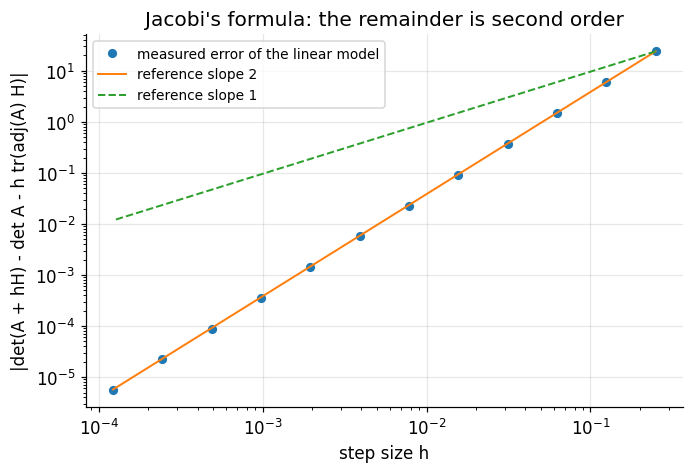

In [7]:
fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.loglog(hs, errs, "o", ms=5, label="measured error of the linear model")
ax.loglog(hs, errs[0] * (hs / hs[0]) ** 2, lw=1.3, label="reference slope 2")
ax.loglog(hs, errs[0] * (hs / hs[0]), lw=1.3, ls="--", label="reference slope 1")
ax.set_xlabel("step size h")
ax.set_ylabel("|det(A + hH) - det A - h tr(adj(A) H)|")
ax.set_title("Jacobi's formula: the remainder is second order")
ax.legend(fontsize=9)
plt.show()

The measured points lie on the slope-$2$ line over five orders of magnitude and are clearly
separated from the slope-$1$ reference. A first-order remainder would mean the trace term was
wrong.

### 7.3 Counterexamples: what breaks when a hypothesis is dropped

Four hypotheses claimed necessary in Section 4, each tested by running the case where it fails.

- **Additivity of $\det$** (Theorem 4.3): the determinant is multilinear in the columns, not
  linear in the matrix.
- **Cyclic, not arbitrary, permutation** (Theorem 4.5):
  $\operatorname{tr}(ABC) \neq \operatorname{tr}(ACB)$.
- **Commuting entries** (Theorem 4.7): over the quaternions, $A = \operatorname{diag}(i, j)$
  fails its own $2 \times 2$ characteristic equation. Quaternions are represented here by the
  standard $2 \times 2$ complex matrices, so a $2 \times 2$ quaternionic matrix becomes a
  $4 \times 4$ complex one.
- **Both factors positive semidefinite** (Theorem 4.13): with only one of them semidefinite the
  Hadamard product can be indefinite.
- **Algebraic closure** (Theorem 4.6 root form, Lemma 4.10): the rotation
  $R = \left[\begin{smallmatrix} 0 & -1 \\ 1 & 0 \end{smallmatrix}\right]$ has no real
  eigenvalue, so it is not similar to any *real* triangular matrix, even though its trace and
  determinant are perfectly well defined.

The cell also runs the bogus "proof" of Cayley-Hamilton that substitutes $t = A$ into
$\det(tI - A)$, to show that it produces a scalar and not a matrix.

In [8]:
print("1. det is not additive")
for P1, P2 in [(np.diag([1.0, 0.0]), np.diag([0.0, 1.0])),
               (np.eye(2), np.eye(2)),
               (np.array([[1.0, 2.0], [3.0, 4.0]]), np.array([[5.0, 6.0], [7.0, 8.0]]))]:
    d1, d2, ds = np.linalg.det(P1), np.linalg.det(P2), np.linalg.det(P1 + P2)
    print(f"   det A = {d1:+.1f}   det B = {d2:+.1f}   det(A+B) = {ds:+.1f}"
          f"   sum would be {d1 + d2:+.1f}")
    assert abs(ds - (d1 + d2)) > 0.5

print("\n2. the trace is cyclic, not symmetric")
Ac = np.array([[1.0, 1.0], [1.0, 2.0]])
Bc = np.array([[1.0, 1.0], [3.0, 1.0]])
Cc = np.array([[1.0, 3.0], [1.0, 1.0]])
print(f"   tr(ABC) = {np.trace(Ac @ Bc @ Cc):.4f}"
      f"   tr(BCA) = {np.trace(Bc @ Cc @ Ac):.4f}"
      f"   tr(CAB) = {np.trace(Cc @ Ac @ Bc):.4f}")
print(f"   tr(ACB) = {np.trace(Ac @ Cc @ Bc):.4f}   <- a non-cyclic reordering, different value")
assert abs(np.trace(Ac @ Bc @ Cc) - np.trace(Bc @ Cc @ Ac)) < 1e-12
assert abs(np.trace(Ac @ Bc @ Cc) - np.trace(Ac @ Cc @ Bc)) > 7.0

print("\n3. Cayley-Hamilton needs commuting entries")
qi = np.array([[1j, 0], [0, -1j]])
qj = np.array([[0, 1 + 0j], [-1, 0]])
qk = qi @ qj
Zq = np.zeros((2, 2), dtype=complex)
Aq = np.block([[qi, Zq], [Zq, qj]])
trace_q = qi + qj
det_q = qi @ qj
resid = Aq @ Aq - np.block([[trace_q, Zq], [Zq, trace_q]]) @ Aq + np.block([[det_q, Zq], [Zq, det_q]])
print("   A = diag(i, j);   A^2 - (i+j) A + (ij) I  should be zero if Cayley-Hamilton held")
print("   top-left quaternion block of the residual:\n", np.round(resid[:2, :2], 10))
print("   the quaternion 2k:\n", np.round(2 * qk, 10))
print(f"   residual Frobenius norm = {np.linalg.norm(resid):.6f}   (zero would mean it holds)")
assert np.allclose(resid[:2, :2], 2 * qk)
assert np.linalg.norm(resid) > 1.0

print("\n4. the Schur product theorem needs both factors PSD")
Ppsd = np.array([[1.0, 0.9], [0.9, 1.0]])
Bind = np.array([[1.0, 2.0], [2.0, 1.0]])
print("   eig(A) =", np.linalg.eigvalsh(Ppsd), " -> PSD")
print("   eig(B) =", np.linalg.eigvalsh(Bind), " -> indefinite")
print("   eig(A o B) =", np.linalg.eigvalsh(Ppsd * Bind), " -> indefinite as well")
assert np.linalg.eigvalsh(Ppsd * Bind).min() < 0

print("\n5. the root form of Theorem 4.6 and Lemma 4.10 need an algebraically closed field")
Rrot = np.array([[0.0, -1.0], [1.0, 0.0]])
print("   R = [[0,-1],[1,0]]")
print("   char polynomial coefficients:", np.poly(Rrot), " -> t^2 + 1, no real root")
print("   complex spectrum:", np.linalg.eigvals(Rrot))
print(f"   tr R = {np.trace(Rrot):.1f} = sum of the complex roots"
      f"   det R = {np.linalg.det(Rrot):.1f} = their product")
print("   a real triangular matrix similar to R would have real diagonal entries equal to")
print("   its eigenvalues, so no real S can triangularize R")
assert np.allclose(np.poly(Rrot), [1.0, 0.0, 1.0])
assert abs(np.linalg.eigvals(Rrot).imag).min() > 0.5

print("\n6. the substitution 'proof' of Cayley-Hamilton")
Xd = np.array([[1.0, 2.0], [3.0, 4.0]])
print(f"   det(A - A) = {np.linalg.det(Xd - Xd):.1f}  <- a scalar")
cX = np.poly(Xd)
PXd = np.zeros((2, 2))
for c in cX:
    PXd = PXd @ Xd + c * np.eye(2)
print("   p_A(A)     =\n", np.round(PXd, 12), "  <- a matrix, and it happens to be zero")
print("   the two objects are not the same kind of thing, so one cannot prove the other")

1. det is not additive
   det A = +0.0   det B = +0.0   det(A+B) = +1.0   sum would be +0.0
   det A = +1.0   det B = +1.0   det(A+B) = +4.0   sum would be +2.0
   det A = -2.0   det B = -2.0   det(A+B) = -8.0   sum would be -4.0

2. the trace is cyclic, not symmetric
   tr(ABC) = 30.0000   tr(BCA) = 30.0000   tr(CAB) = 30.0000
   tr(ACB) = 22.0000   <- a non-cyclic reordering, different value

3. Cayley-Hamilton needs commuting entries
   A = diag(i, j);   A^2 - (i+j) A + (ij) I  should be zero if Cayley-Hamilton held
   top-left quaternion block of the residual:
 [[0.+0.j 0.+2.j]
 [0.+2.j 0.+0.j]]
   the quaternion 2k:
 [[0.+0.j 0.+2.j]
 [0.+2.j 0.+0.j]]
   residual Frobenius norm = 2.828427   (zero would mean it holds)

4. the Schur product theorem needs both factors PSD
   eig(A) = [0.1 1.9]  -> PSD
   eig(B) = [-1.  3.]  -> indefinite
   eig(A o B) = [-0.8  2.8]  -> indefinite as well

5. the root form of Theorem 4.6 and Lemma 4.10 need an algebraically closed field
   R = [[0,-1]

The first pair is the sharpest possible failure: two singular matrices, each of determinant
$0$, whose sum is the identity with determinant $1$. The other two pairs are off by a factor of
two. None of this is a rounding effect; it is an $O(1)$ error.

The three cyclic rotations of $ABC$ all give $30$ while the swap $ACB$ gives $22$. Only
rotations are theorems.

The quaternionic residual is exactly $\operatorname{diag}(2k, 0)$, matching the hand computation
in Theorem 4.7 and confirming that commutativity is doing real work in Proof 5.7.

Dropping semidefiniteness from one factor makes the Hadamard product indefinite, with a negative
eigenvalue near $-0.8$: the conclusion of Theorem 4.13 fails, not merely its proof.

The rotation has characteristic polynomial $t^{2} + 1$ and no real root, so Lemma 4.10 has no
real analogue — yet $\operatorname{tr}R = 0$ and $\det R = 1$ still equal the sum and product of
its two complex eigenvalues, which is why Theorem 4.6's minor formula holds over every field
while its root form needs $\mathbb{C}$.

Finally, $\det(A - A)$ is the number $0$ while $p_A(A)$ is the zero *matrix*. Both happen to
vanish here, which is exactly why the fake argument is seductive; the objects are of different
types and no substitution connects them.

### 7.4 Hand-rolled against the library

Three implementations written from the definitions in this module, each checked against the
corresponding NumPy routine:

- the **Leibniz formula**, summing $n!$ signed products, against `numpy.linalg.det`;
- **Gaussian elimination with partial pivoting**, the $\mathcal{O}(n^{3})$ route, against the
  same;
- the **Faddeev-LeVerrier** recursion, which produces the characteristic polynomial from traces
  alone using Theorem 4.6, against `numpy.poly`.

The cell also times Leibniz against elimination at $n = 9$, to put a number on the remark after
Proof 5.4.

In [9]:
import time
from math import factorial

def det_leibniz(M):
    """Determinant by the Leibniz formula of Theorem 4.1: n! signed products."""
    n = M.shape[0]
    total = 0.0
    for perm in itertools.permutations(range(n)):
        total += sign_of(perm) * prod(M[perm[j], j] for j in range(n))
    return total

def det_elimination(M):
    """Determinant by Gaussian elimination with partial pivoting."""
    W = M.astype(float).copy()
    n = W.shape[0]
    sign = 1.0
    for k in range(n - 1):
        p = k + int(np.argmax(np.abs(W[k:, k])))
        if p != k:
            W[[k, p]] = W[[p, k]]
            sign = -sign
        if W[k, k] == 0.0:
            return 0.0
        W[k + 1:, k:] -= np.outer(W[k + 1:, k] / W[k, k], W[k, k:])
    return sign * np.prod(np.diag(W))

def faddeev_leverrier(M):
    """Characteristic polynomial coefficients, highest power first."""
    n = M.shape[0]
    N = np.zeros_like(M, dtype=float)
    c = np.zeros(n + 1)
    c[0] = 1.0
    for k in range(1, n + 1):
        N = M @ N + c[k - 1] * np.eye(n)
        c[k] = -np.trace(M @ N) / k
    return c

Z = rng.standard_normal((7, 7))
d_lib = np.linalg.det(Z)
d_lei = det_leibniz(Z)
d_eli = det_elimination(Z)
print("determinant of a random 7x7")
print(f"  numpy.linalg.det : {d_lib:.15f}")
print(f"  Leibniz          : {d_lei:.15f}   relative difference {abs(d_lei - d_lib) / abs(d_lib):.3e}")
print(f"  elimination      : {d_eli:.15f}   relative difference {abs(d_eli - d_lib) / abs(d_lib):.3e}")
assert abs(d_lei - d_lib) / abs(d_lib) < 1e-10
assert abs(d_eli - d_lib) / abs(d_lib) < 1e-12

c_fl = faddeev_leverrier(Z)
c_np = np.poly(Z)
print("\ncharacteristic polynomial of the same matrix")
print("  Faddeev-LeVerrier :", c_fl)
print("  numpy.poly        :", c_np)
print(f"  max |difference|  = {np.abs(c_fl - c_np).max():.3e}")
assert np.abs(c_fl - c_np).max() < 1e-9

print("\ncost of the two determinant algorithms at n = 9")
W10 = rng.standard_normal((9, 9))
t0 = time.perf_counter(); det_leibniz(W10); t_lei = time.perf_counter() - t0
t0 = time.perf_counter(); det_elimination(W10); t_eli = time.perf_counter() - t0
print(f"  Leibniz     : {t_lei * 1e3:9.2f} ms   ({factorial(9):,} signed products)")
print(f"  elimination : {t_eli * 1e3:9.2f} ms")
print(f"  ratio       : {t_lei / t_eli:9.1f}x")

determinant of a random 7x7
  numpy.linalg.det : 165.731296693414635
  Leibniz          : 165.731296693414407   relative difference 1.372e-15
  elimination      : 165.731296693414606   relative difference 1.715e-16

characteristic polynomial of the same matrix
  Faddeev-LeVerrier : [   1.       -0.5343    8.8633   20.4161  -47.8907 -146.9691  103.8403
 -165.7313]
  numpy.poly        : [   1.       -0.5343    8.8633   20.4161  -47.8907 -146.9691  103.8403
 -165.7313]
  max |difference|  = 2.274e-13

cost of the two determinant algorithms at n = 9


  Leibniz     :   1036.72 ms   (362,880 signed products)
  elimination :      0.34 ms
  ratio       :    3025.8x


All three hand-written routines agree with the library. Leibniz agrees to a relative
$1.4 \times 10^{-15}$, elimination to $1.7 \times 10^{-16}$, and Faddeev-LeVerrier reproduces all
eight coefficients of the characteristic polynomial of the $7 \times 7$ example.

The timing makes the complexity remark concrete: at $n = 9$ the Leibniz sum evaluates
$362{,}880$ signed products and runs thousands of times slower than elimination. At $n = 20$ it
would need $2.4 \times 10^{18}$ of them, which no amount of hardware fixes.

Faddeev-LeVerrier is worth noting on its own: it computes the coefficients $E_k(A)$ of
Theorem 4.6 from $n$ matrix multiplications and $n$ traces, without ever forming a single minor.

### 7.5 The Kronecker spectrum is a product grid

The final experiment draws Theorem 4.11. Take

$$
A = \begin{pmatrix} 1 & -1 & 0 \\ 1 & 1 & 0 \\ 0 & 0 & 2 \end{pmatrix},
\qquad
B = \begin{pmatrix} 0 & -1 \\ 1 & 0 \end{pmatrix},
$$

with $\operatorname{spec}(A) = \{ 1 + i, \, 1 - i, \, 2 \}$ and
$\operatorname{spec}(B) = \{ i, -i \}$. Theorem 4.11 predicts that the six eigenvalues of
$A \otimes B$ are the six products, and the figure overlays the computed spectrum on that
predicted grid.

spec(A)          : [1.+1.j 1.-1.j 2.+0.j]
spec(B)          : [0.+1.j 0.-1.j]
predicted products: [-1.-1.j -1.+1.j  0.-2.j  0.+2.j  1.-1.j  1.+1.j]
spec(A kron B)   : [-1.-1.j -1.+1.j  0.-2.j  0.+2.j  1.-1.j  1.+1.j]
max |difference| = 8.006e-16
det(A kron B) = 16.0000000000   (det A)^2 (det B)^3 = 16.0000000000
tr(A kron B)  = 0.0000000000   tr(A) tr(B) = 0.0000000000


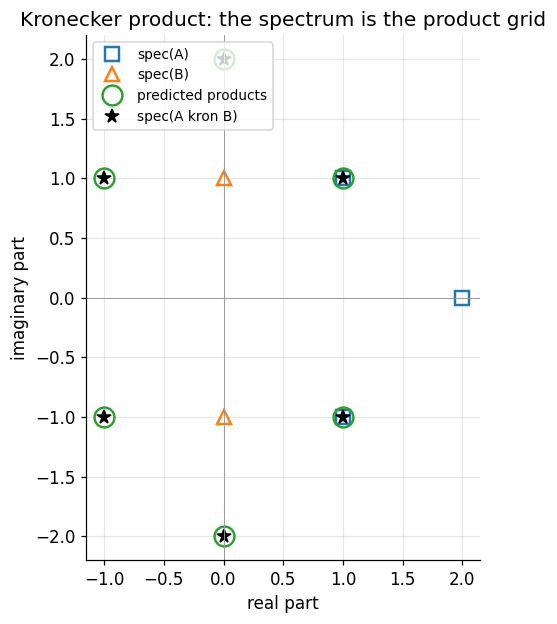

In [10]:
Akr = np.array([[1.0, -1.0, 0.0], [1.0, 1.0, 0.0], [0.0, 0.0, 2.0]])
Bkr = np.array([[0.0, -1.0], [1.0, 0.0]])
Kkr = np.kron(Akr, Bkr)

lamA = np.linalg.eigvals(Akr)
lamB = np.linalg.eigvals(Bkr)
predicted = np.array([a * b for a in lamA for b in lamB])
actual = np.linalg.eigvals(Kkr)

order_p = np.lexsort((predicted.imag.round(9), predicted.real.round(9)))
order_a = np.lexsort((actual.imag.round(9), actual.real.round(9)))
print("spec(A)          :", np.round(lamA, 6))
print("spec(B)          :", np.round(lamB, 6))
print("predicted products:", np.round(predicted[order_p], 6))
print("spec(A kron B)   :", np.round(actual[order_a], 6))
print(f"max |difference| = {np.abs(predicted[order_p] - actual[order_a]).max():.3e}")
print(f"det(A kron B) = {np.linalg.det(Kkr):.10f}   "
      f"(det A)^2 (det B)^3 = {np.linalg.det(Akr) ** 2 * np.linalg.det(Bkr) ** 3:.10f}")
print(f"tr(A kron B)  = {np.trace(Kkr):.10f}   tr(A) tr(B) = {np.trace(Akr) * np.trace(Bkr):.10f}")
assert np.abs(predicted[order_p] - actual[order_a]).max() < 1e-10

fig, ax = plt.subplots(figsize=(6.2, 6.2))
ax.plot(lamA.real, lamA.imag, "s", ms=9, mfc="none", mew=1.6, label="spec(A)")
ax.plot(lamB.real, lamB.imag, "^", ms=9, mfc="none", mew=1.6, label="spec(B)")
ax.plot(predicted.real, predicted.imag, "o", ms=13, mfc="none", mew=1.6,
        label="predicted products")
ax.plot(actual.real, actual.imag, "k*", ms=9, label="spec(A kron B)")
ax.axhline(0.0, lw=0.6, color="0.6")
ax.axvline(0.0, lw=0.6, color="0.6")
ax.set_aspect("equal")
ax.set_xlabel("real part")
ax.set_ylabel("imaginary part")
ax.set_title("Kronecker product: the spectrum is the product grid")
ax.legend(fontsize=9, loc="upper left")
plt.show()

Every star sits inside a circle: the six eigenvalues of $A \otimes B$ are exactly the six
products $\lambda_i \mu_j$, to $10^{-15}$. That is the exhaustion statement of Theorem 4.11, the
part that the elementary eigenvector argument cannot reach.

The determinant and trace read off the same picture: the product of the six points is
$16 = (\det A)^{2}(\det B)^{3}$ and their sum is $0 = \operatorname{tr}(A)\operatorname{tr}(B)$.

## 8. Applications

Four settings in which one of the results above is the engine rather than the decoration.

### 8.1 Log-determinants: Gaussian models and normalizing flows

The log-density of $\mathcal{N}(\mu, \Sigma)$ in $\mathbb{R}^{d}$ is

$$
\log p(x) = -\tfrac{1}{2}(x-\mu)^{\top}\Sigma^{-1}(x-\mu) - \tfrac{1}{2}\log \det \Sigma - \tfrac{d}{2}\log(2\pi),
$$

so fitting a Gaussian means differentiating $\log\det\Sigma$. Theorem 4.9 gives that derivative
immediately:

$$
\frac{\partial}{\partial \Sigma} \log \det \Sigma = \Sigma^{-1} \quad \text{for symmetric } \Sigma .
$$

Numerically the determinant itself must never be formed: for $d = 200$ and a covariance scaled
by $100$ it exceeds the double-precision range, while $\log\det$ is a number near $10^{3}$. The
right computation is $\log\det\Sigma = 2\sum_i \log L_{ii}$ from the Cholesky factor
$\Sigma = LL^{\top}$, which is exactly Theorem 4.3 applied to a triangular factorization.

A **normalizing flow** pushes a simple density through an invertible map $x = f(z)$ and pays the
change-of-variables price

$$
\log p_X(x) = \log p_Z(z) - \log \bigl\lvert \det J_f(z) \bigr\rvert .
$$

Its continuous-time version replaces the map by a flow $\dot{z} = g(z, t)$, and Theorem 4.9 turns
the determinant into a trace:

$$
\frac{d}{dt} \log p(z(t)) = -\operatorname{tr}\!\left( \frac{\partial g}{\partial z} \right).
$$

Estimating that trace without forming the Jacobian is the **Hutchinson estimator**: for a random
vector $z$ with independent entries of mean $0$ and variance $1$,

$$
\mathbb{E}\bigl[ z^{\top} M z \bigr] = \operatorname{tr}(M),
$$

because $\mathbb{E}[z^{\top}Mz] = \mathbb{E}[\operatorname{tr}(M z z^{\top})] = \operatorname{tr}(M \mathbb{E}[zz^{\top}]) = \operatorname{tr}(M)$
by Theorem 4.5. Its error decays as $m^{-1/2}$ in the number of probes, and the cell below
measures that exponent.

### 8.2 Kronecker structure: K-FAC and the Sylvester equation

For a linear layer $y = Wx$ with $W \in \mathbb{R}^{p \times q}$, the Fisher information matrix
over $\operatorname{vec}(W)$ has $\left( pq \right)^{2}$ entries. **K-FAC** approximates it as a
Kronecker product

$$
F \approx \Sigma_x \otimes \Sigma_g, \qquad \Sigma_x = \mathbb{E}[x x^{\top}] \in \mathbb{R}^{q \times q}, \quad \Sigma_g = \mathbb{E}[g g^{\top}] \in \mathbb{R}^{p \times p},
$$

with $g$ the gradient of the loss with respect to $y$. The mixed-product property of
Theorem 4.11 inverts it factor by factor, and the vec identity turns the natural-gradient step
into two small solves:

$$
F^{-1} \operatorname{vec}(G) = \bigl( \Sigma_x^{-1} \otimes \Sigma_g^{-1} \bigr) \operatorname{vec}(G) = \operatorname{vec}\bigl( \Sigma_g^{-1} G \, \Sigma_x^{-1} \bigr) .
$$

Forming and inverting $F$ costs $\mathcal{O}(p^{3}q^{3})$; the right-hand side costs
$\mathcal{O}(p^{3} + q^{3})$.

The same identity linearizes a matrix equation. The **Sylvester equation** $AX + XB = C$ becomes

$$
\bigl( I \otimes A + B^{\top} \otimes I \bigr) \operatorname{vec}(X) = \operatorname{vec}(C),
$$

an ordinary linear system, and by Theorem 4.11 its coefficient matrix has eigenvalues
$\lambda_i(A) + \mu_j(B)$ — so the equation has a unique solution exactly when $A$ and $-B$ have
no eigenvalue in common.

### 8.3 Counting spanning trees: the Matrix-Tree theorem

For an undirected graph on $n$ vertices with adjacency matrix $W$ and degree matrix $D$, the
Laplacian is $L = D - W$. Every row and column of $L$ sums to zero, so $L$ is singular and
$\det L = 0$ carries no information. Its **cofactors** do.

> **Matrix-Tree theorem (cited, not proved here).** All $n^{2}$ cofactors of $L$ are equal, and
> their common value is the number of spanning trees of the graph. See Bollobás, *Modern Graph
> Theory*, section II.3 (Theorem II.12), or Stanley, *Enumerative Combinatorics* volume 2,
> Theorem 5.6.8. The proof applies the Cauchy-Binet formula to the incidence matrix, and it is
> carried out in full in Problem L3.10 of this module's exercises.

This is the cleanest possible illustration of what a determinant is for: a purely combinatorial
count, extracted from a single $(n-1) \times (n-1)$ determinant. It is developed further in
[graph_theory/03](../../graph_theory/03_trees_and_minimum_spanning_trees/).

### 8.4 Physics: Liouville's theorem and Abel's identity

Consider a linear system $\dot{x} = M x$ with fundamental matrix $\Phi(t)$, defined by
$\dot{\Phi} = M \Phi$ and $\Phi(0) = I$. Theorem 4.9 gives

$$
\frac{d}{dt}\det\Phi(t) = \det\Phi(t) \cdot \operatorname{tr}\bigl( \Phi^{-1} M \Phi \bigr) = \det\Phi(t) \cdot \operatorname{tr}(M),
$$

using cyclic invariance, so

$$
\boxed{\ \det \Phi(t) = e^{t \operatorname{tr}(M)}\ }
$$

This is **Abel's identity**, and $\det\Phi$ is the **Wronskian** when the system comes from a
scalar second-order equation $y'' + p y' + q y = 0$: there $M = \left[\begin{smallmatrix} 0 & 1 \\ -q & -p \end{smallmatrix}\right]$
has trace $-p$, giving $W(t) = W(0)e^{-\int p}$.

For a Hamiltonian system the Jacobian of the flow is $J \nabla^{2}H$ with
$J = \left[\begin{smallmatrix} 0 & I \\ -I & 0 \end{smallmatrix}\right]$, and a direct
computation shows $\operatorname{tr}(J \nabla^{2}H) = 0$. Hence $\det\Phi(t) = 1$: **phase-space
volume is conserved**, which is Liouville's theorem. Add linear damping and the trace becomes
negative, so volume contracts exponentially at the rate given by the trace.

The harmonic oscillator makes both cases explicit:

$$
M_{\text{cons}} = \begin{pmatrix} 0 & 1 \\ -4 & 0 \end{pmatrix}, \ \operatorname{tr} = 0
\qquad \text{versus} \qquad
M_{\text{damp}} = \begin{pmatrix} 0 & 1 \\ -4 & -0.3 \end{pmatrix}, \ \operatorname{tr} = -0.3 .
$$

The cell below runs all four applications: the log-determinant of a $200 \times 200$ covariance
that overflows as a determinant, the Hutchinson estimator with its measured convergence
exponent, the K-FAC identity, the spanning-tree count of an explicit five-edge graph checked
against brute-force enumeration, and Abel's identity for the two oscillators.

In [11]:
from scipy.linalg import expm

print("8.1 log-determinants")
G200 = rng.standard_normal((200, 200))
Sigma = 100.0 * (G200 @ G200.T / 200.0 + np.eye(200))
Lc = np.linalg.cholesky(Sigma)
sign, logabsdet = np.linalg.slogdet(Sigma)
with np.errstate(over="ignore"):
    det_overflow = np.linalg.det(Sigma)
print(f"  numpy.linalg.det      : {det_overflow:.6e}   (double precision overflows near 1.8e308)")
print(f"  slogdet log|det|      : {logabsdet:.10f}   sign {sign:.0f}")
print(f"  2 * sum log diag(L)   : {2 * np.log(np.diag(Lc)).sum():.10f}")
assert not np.isfinite(det_overflow)
assert abs(2 * np.log(np.diag(Lc)).sum() - logabsdet) < 1e-8

print("\n  Hutchinson trace estimator")
Mh = rng.standard_normal((60, 60))
Mh = Mh @ Mh.T / 60.0
tr_true = np.trace(Mh)
ms = np.array([4, 16, 64, 256, 1024])
rms = []
for m in ms:
    errs = []
    for _ in range(300):
        Zp = rng.choice([-1.0, 1.0], size=(60, m))
        est = np.mean(np.einsum("ij,ij->j", Zp, Mh @ Zp))
        errs.append(est - tr_true)
    rms.append(np.sqrt(np.mean(np.square(errs))))
rms = np.array(rms)
exponent = np.polyfit(np.log(ms), np.log(rms), 1)[0]
print(f"  true trace = {tr_true:.6f}")
for m, r in zip(ms, rms):
    print(f"    m = {m:5d}   rms error = {r:.6f}")
print(f"  fitted exponent = {exponent:.4f}   predicted -0.5")
assert abs(exponent + 0.5) < 0.06

print("\n8.2 K-FAC natural gradient without forming the Fisher matrix")
q, p = 4, 3
Sx = rng.standard_normal((q, q)); Sx = Sx @ Sx.T + q * np.eye(q)
Sg = rng.standard_normal((p, p)); Sg = Sg @ Sg.T + p * np.eye(p)
Gw = rng.standard_normal((p, q))
F = np.kron(Sx, Sg)
direct = np.linalg.solve(F, Gw.reshape(-1, order="F"))
smart = (np.linalg.solve(Sg, Gw) @ np.linalg.inv(Sx)).reshape(-1, order="F")
print(f"  Fisher matrix is {F.shape[0]} x {F.shape[1]};  two factors are {q}x{q} and {p}x{p}")
print(f"  relative difference between the two routes = {np.linalg.norm(direct - smart) / np.linalg.norm(smart):.3e}")
assert np.linalg.norm(direct - smart) / np.linalg.norm(smart) < 1e-10

print("\n8.3 Matrix-Tree theorem on a 4-vertex graph")
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
Wg = np.zeros((4, 4))
for a, b in edges:
    Wg[a, b] = Wg[b, a] = 1.0
Lg = np.diag(Wg.sum(axis=1)) - Wg
cofactors = [round(np.linalg.det(np.delete(np.delete(Lg, i, 0), i, 1))) for i in range(4)]
brute = 0
for sub in itertools.combinations(edges, 3):
    Ms = np.zeros((4, 4))
    for a, b in sub:
        Ms[a, b] = Ms[b, a] = 1.0
    if np.linalg.matrix_rank(np.diag(Ms.sum(axis=1)) - Ms) == 3:
        brute += 1
print("  Laplacian =\n", Lg.astype(int))
print("  the four principal cofactors :", cofactors)
print("  spanning trees by enumeration:", brute)
assert cofactors == [brute] * 4

print("\n8.4 Abel's identity for two oscillators")
for M, name in [(np.array([[0.0, 1.0], [-4.0, 0.0]]), "conservative"),
                (np.array([[0.0, 1.0], [-4.0, -0.3]]), "damped")]:
    print(f"  {name}: tr M = {np.trace(M):+.1f}")
    for t0 in (0.5, 1.0, 2.0):
        Phi = expm(M * t0)
        print(f"    t = {t0:.1f}   det Phi(t) = {np.linalg.det(Phi):.12f}"
              f"   exp(t tr M) = {np.exp(t0 * np.trace(M)):.12f}")
        assert abs(np.linalg.det(Phi) - np.exp(t0 * np.trace(M))) < 1e-10

8.1 log-determinants
  numpy.linalg.det      : inf   (double precision overflows near 1.8e308)
  slogdet log|det|      : 1037.4608800974   sign 1
  2 * sum log diag(L)   : 1037.4608800974

  Hutchinson trace estimator


  true trace = 60.365992
    m =     4   rms error = 5.464420
    m =    16   rms error = 2.786849
    m =    64   rms error = 1.401704
    m =   256   rms error = 0.748352
    m =  1024   rms error = 0.347325
  fitted exponent = -0.4924   predicted -0.5

8.2 K-FAC natural gradient without forming the Fisher matrix
  Fisher matrix is 12 x 12;  two factors are 4x4 and 3x3
  relative difference between the two routes = 2.937e-16

8.3 Matrix-Tree theorem on a 4-vertex graph
  Laplacian =
 [[ 3 -1 -1 -1]
 [-1  2 -1  0]
 [-1 -1  3 -1]
 [-1  0 -1  2]]
  the four principal cofactors : [8, 8, 8, 8]
  spanning trees by enumeration: 8

8.4 Abel's identity for two oscillators
  conservative: tr M = +0.0
    t = 0.5   det Phi(t) = 1.000000000000   exp(t tr M) = 1.000000000000
    t = 1.0   det Phi(t) = 1.000000000000   exp(t tr M) = 1.000000000000
    t = 2.0   det Phi(t) = 1.000000000000   exp(t tr M) = 1.000000000000
  damped: tr M = -0.3
    t = 0.5   det Phi(t) = 0.860707976425   exp(t tr M) =

The $200 \times 200$ covariance has a determinant that overflows to infinity in double precision,
while its log-determinant is a comfortable $1037.461$; the Cholesky route and `slogdet` agree to
ten decimals. This is why every serious Gaussian implementation stores $\log\det$, never
$\det$.

The Hutchinson estimator's root-mean-square error falls with a fitted exponent of $-0.492$
against the predicted $-0.5$: quadrupling the number of probes halves the error, which is the
ordinary Monte-Carlo rate and the reason continuous normalizing flows can afford a trace but not
a determinant.

K-FAC replaces a $12 \times 12$ solve by a $3 \times 3$ and a $4 \times 4$ one and returns the
identical vector to machine precision; at realistic layer sizes the same substitution turns an
impossible computation into a cheap one.

All four cofactors of the Laplacian equal $8$, and brute-force enumeration over the
$\binom{5}{3} = 10$ three-edge subsets finds exactly $8$ spanning trees.

Finally, the conservative oscillator has $\det\Phi(t) = 1$ to twelve decimals at every sampled
time — phase-space volume conserved — while the damped one contracts as $e^{-0.3t}$, matching
$e^{t\operatorname{tr}M}$ exactly.

## 9. Key Takeaways

- **The determinant is the unique multilinear alternating normalized function of the columns**,
  and that uniqueness is a proof technique, not a slogan: build any multilinear alternating
  gadget and it is $\det$ times its value on the identity (Theorem 4.1). Proofs 5.3, 5.4, 5.6
  and 5.11 are all that one move.

- **Transpose invariance comes before row operations, not after** (Theorem 4.2). The axioms are
  stated on columns, so any argument that scales or swaps a *row* is illegitimate until
  $\det(A^{\top}) = \det(A)$ is available.

- **Composition multiplies volume factors**: $\det(AB) = \det(A)\det(B)$, hence the singularity
  test, the block triangular rule, and similarity invariance (Theorem 4.3). Addition does
  nothing of the kind, and Section 7 shows $\det(A+B)$ off by a factor of four.

- **Trace and determinant are the two ends of one list.** The coefficients of
  $\det(tI - A)$ are the signed sums of principal minors, with $E_1 = \operatorname{tr}$ and
  $E_n = \det$; over $\mathbb{C}$ they are the elementary symmetric functions of the eigenvalues
  (Theorem 4.6).

- **Cayley-Hamilton, $p_A(A) = 0$, is proved by comparing coefficients of a matrix polynomial
  identity** (Proof 5.7), never by substituting $t = A$ into a scalar determinant. Its price is
  commutativity: over the quaternions, $\operatorname{diag}(i,j)$ misses its own characteristic
  equation by $\operatorname{diag}(2k, 0)$.

- **The minimal polynomial divides the characteristic one and shares its roots** (Theorem 4.8).
  The gap between their multiplicities is the whole of non-diagonalizability; Example 6.6 has
  $\deg m = 3$ against $\deg p = 4$.

- **The trace is the logarithmic derivative of the determinant**:
  $\frac{d}{dt}\log\lvert\det A(t)\rvert = \operatorname{tr}(A^{-1}A')$, and separately
  $\det(e^{A}) = e^{\operatorname{tr}A}$ (Theorem 4.9). Section 7 measures the second-order
  remainder and gets a fitted order of $2.0050$ against a predicted $2$.

- **The Kronecker product multiplies spectra with the right multiplicities**, which needs
  triangularization and not just the eigenvector identity, and gives
  $\det(A \otimes B) = (\det A)^{m}(\det B)^{n}$ (Theorem 4.11). The Hadamard product multiplies
  nothing, but it does preserve the positive semidefinite cone (Theorem 4.13).

## 10. References

**Textbooks.**

- Axler, S. *Linear Algebra Done Right*, 3rd ed., chapter 10 — trace and determinant defined
  through operators and generalized eigenvectors rather than through permutations.
- Horn, R. A. and Johnson, C. R. *Matrix Analysis*, 2nd ed. — determinants and the Leibniz
  formula (section 0.3), the adjugate and Cramer's rule (section 0.8), the characteristic
  polynomial and its principal-minor coefficients (section 1.2), Cayley-Hamilton and the minimal
  polynomial (section 2.4), the Schur product theorem (Theorem 7.5.3).
- Horn, R. A. and Johnson, C. R. *Topics in Matrix Analysis* — the Kronecker product and the
  vec identity (chapter 4), the Hadamard product (chapter 5).
- Strang, G. *Introduction to Linear Algebra*, 5th ed., chapter 5 — the three defining
  properties of the determinant (section 5.1), permutations and cofactors (section 5.2),
  Cramer's rule, inverses and volumes (section 5.3).
- Meyer, C. D. *Matrix Analysis and Applied Linear Algebra*, section 6.1 (determinants) and
  section 7.3 (functions of a matrix, Cayley-Hamilton in use).
- Golub, G. H. and Van Loan, C. F. *Matrix Computations*, 4th ed., section 1.3.6 (Kronecker
  products), section 3.2 (determinants through LU), section 12.3 (Kronecker product
  computations).
- Bollobás, B. *Modern Graph Theory*, section II.3 — the Matrix-Tree theorem quoted in
  Section 8.

**Papers.**

- Van Loan, C. F. "The ubiquitous Kronecker product", *Journal of Computational and Applied
  Mathematics* **123** (2000), 85-100.
- Martens, J. and Grosse, R. "Optimizing neural networks with Kronecker-factored approximate
  curvature", *ICML* (2015) — the approximation used in Section 8.2.
- Hutchinson, M. F. "A stochastic estimator of the trace of the influence matrix for Laplacian
  smoothing splines", *Communications in Statistics - Simulation and Computation* **19**(2)
  (1990), 433-450.
- Chen, R. T. Q., Rubanova, Y., Bettencourt, J. and Duvenaud, D. "Neural ordinary differential
  equations", *NeurIPS* (2018) — the instantaneous change-of-variables formula that turns
  $\log\det$ into a trace.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions: [the notation register](../../docs/notation.md).
- Linear maps, similarity and change of basis, used throughout:
  [Module 02](../02_linear_maps_and_matrix_transformations/).
- The Cholesky factorization used in Proof 5.13:
  [Module 03](../03_linear_systems_and_direct_factorizations/).
- Eigenvectors, diagonalizability and the spectral theorem, which take over where this module's
  root-counting stops: [Module 06](../06_eigenvalues_eigenvectors_spectral_theory/).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).